# CGB ecosystem simulation — executed results

Read the [complete Markdown report](REPORT.md) for all derivations, assumptions, source research and interpretation. These are **synthetic experiments**, not empirical trading returns. The code below reads the saved outputs of all 11 experiments. Every table and plot output was executed and captured.

The 60/120/240-minute books are separate. A blank score means no observable target; a blank P&L means an unpriced open trade made the book incomplete. Zero P&L with zero trades is a distinct outcome.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image
locations = [Path.cwd()] + [p / 'research' / 'cgb_ecosystem' for p in [Path.cwd(), *Path.cwd().parents]]
ROOT = next(p for p in locations if (p / 'protocol.json').exists())
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
print('Results folder:', ROOT)
print(json.dumps(json.loads((ROOT / 'protocol.json').read_text()), indent=2))

Results folder: C:\Users\mn262\OneDrive\Desktop\momentum\research\cgb_ecosystem
{
  "version": "2.0-bond-ecosystem",
  "seeds": [
    1729,
    2718,
    3141
  ],
  "sessions": 40,
  "train_sessions": 24,
  "calibration_sessions": 8,
  "test_sessions": 8,
  "session_minutes": 480,
  "session_timezone": "America/New_York",
  "session_open": "08:00",
  "session_close": "16:00",
  "horizons_minutes": [
    60,
    120,
    240
  ],
  "decision_minutes": 5,
  "model_trees": 100,
  "modules": [
    "cgb",
    "us",
    "curve",
    "book",
    "vwap"
  ],
  "stress_worlds": [
    "fast_decay",
    "liquidity_shock",
    "decoupling",
    "feed_gaps"
  ],
  "entry_delay_minutes": 1,
  "contracts": 1,
  "signal_threshold": 0.2,
  "roundtrip_fee_cad": 4.0,
  "base_extra_slippage_ticks": 1.0,
  "stressed_extra_slippage_ticks": 4.0,
  "costs_are_assumptions": true,
  "market_calibrated": false,
  "no_threshold_or_parameter_selection_on_test": true
}


## All forecast scores

Lower log loss is better. The difference is model loss minus a constant TRAIN-frequency forecast. Eight sessions per TEST history contain many overlapping forecasts; row count is not independent sample size.

In [2]:
metrics = pd.read_csv(ROOT / 'metrics.csv')
print(metrics.to_string(index=False))

                 run  horizon_minutes  forecasts  scored  missing_outcomes  sessions  log_loss    brier  baseline_log_loss  loss_difference  difference_ci_low  difference_ci_high  endpoint_mae_ticks  zero_forecast_mae_ticks  endpoint_rmse_ticks  zero_forecast_rmse_ticks  interval_80_coverage  interval_80_width  long_mae80_coverage  short_mae80_coverage  mean_scenario_ess  mean_nearest_distance  feature_coverage  flow_coverage
           base-1729               60        576     576                 0         8  0.951583 0.564169           1.060046        -0.108463          -0.135033           -0.080633           10.122786                11.713542            13.537295                 16.021118              0.850694          38.662808             0.868056              0.826389        1240.110679               0.427527          0.978261           1.00
           base-1729              120        480     480                 0         8  0.974542 0.586295           1.011996        -0.037454 

## All trading books

One-minute entry delay; price bid/ask; C$4 roundtrip fees; one extra slippage tick in the base ledger and four in the cost stress. The incomplete-book flag suppresses aggregate P&L when any opened trade has an unpriced exit.

In [3]:
execution = pd.read_csv(ROOT / 'execution-summary.csv')
print(execution.to_string(index=False))
assert len(execution) == 11 * 3 * 4

                 run  horizon_minutes        strategy  trades  long_trades  short_trades  gross_cad  spread_cad  extra_slippage_cad  fees_cad  net_cad  stress_net_cad  win_fraction  max_drawdown_cad  held_minutes  priced_subset_net_cad  unpriced_trades              accounting_status
           base-1729               60     always_long      48           48             0    -1285.0       645.0               480.0     192.0  -2602.0         -4042.0      0.333333            3532.0        2832.0                -2602.0                0           complete_priced_book
           base-1729               60    always_short      48            0            48     1285.0       645.0               480.0     192.0    -32.0         -1472.0      0.479167            1615.0        2832.0                  -32.0                0           complete_priced_book
           base-1729               60           model      41           14            27     4765.0       535.0               410.0     164.0   3656

## Calibration and path-risk scores

In [4]:
print(pd.read_csv(ROOT / 'fitted-weights.csv').to_string(index=False))
print(pd.read_csv(ROOT / 'proper-path-scores.csv').to_string(index=False))

      run  horizon_minutes  state_ml_weight  local_weight  structural_weight  supervised_weight  train_paths  cal_paths  test_paths
base-1729               60         0.782337  1.512739e-16       0.000000e+00       1.000000e+00         1728        576         576
base-1729              120         0.734223  9.320924e-18       2.280489e-01       7.719511e-01         1440        480         480
base-1729              240         0.000006  0.000000e+00       3.228879e-01       6.771121e-01          864        288         288
null-1729               60         0.112470  7.403594e-17       5.565045e-01       4.434955e-01         1728        576         576
null-1729              120         0.344155  3.329170e-16       6.418779e-01       3.581221e-01         1440        480         480
null-1729              240         0.055236  0.000000e+00       1.000000e+00       9.714451e-17          864        288         288
base-2718               60         0.135949  2.775558e-17       0.000000e+00

## The priced instruments

Cash-flow prices, accrued interest and sensitivities are derived from explicit discount curves. Securities, exchange factors and calendars use declared synthetic conventions.

In [5]:
specifications = pd.read_csv(ROOT / 'results/base-1729/inputs/bond_specs.csv.gz')
bonds = pd.read_csv(ROOT / 'results/base-1729/inputs/cash_bonds.csv.gz')
futures = pd.read_csv(ROOT / 'results/base-1729/inputs/futures_valuation.csv.gz')
print(specifications.to_string(index=False))
print(bonds.groupby('instrument').first()[['clean','dirty','accrued','yield_bp','dv01_per_100k']].to_string())
print(futures.groupby('instrument').first()[['fair','bid','ask','ctd','dv01']].to_string())

instrument  initial_maturity_years  coupon     group  conversion_factor  delivery_year_fraction
      CAD2                    2.25  0.0300 benchmark                NaN                0.328767
      CAD5                    5.25  0.0325 benchmark                NaN                0.328767
     CAD10                   10.25  0.0350 benchmark                NaN                0.328767
     CGZ_A                    1.75  0.0300       CGZ           0.959677                0.328767
     CGZ_B                    2.25  0.0400       CGZ           0.964172                0.328767
     CGF_A                    4.25  0.0300       CGF           0.896518                0.328767
     CGF_B                    5.25  0.0400       CGF           0.915817                0.328767
     CGB_A                    8.25  0.0300       CGB           0.813008                0.328767
     CGB_B                    9.25  0.0400       CGB           0.863340                0.328767
     CGB_C                   10.25  0.04

## Market construction and diagnostics

01-experiment.png


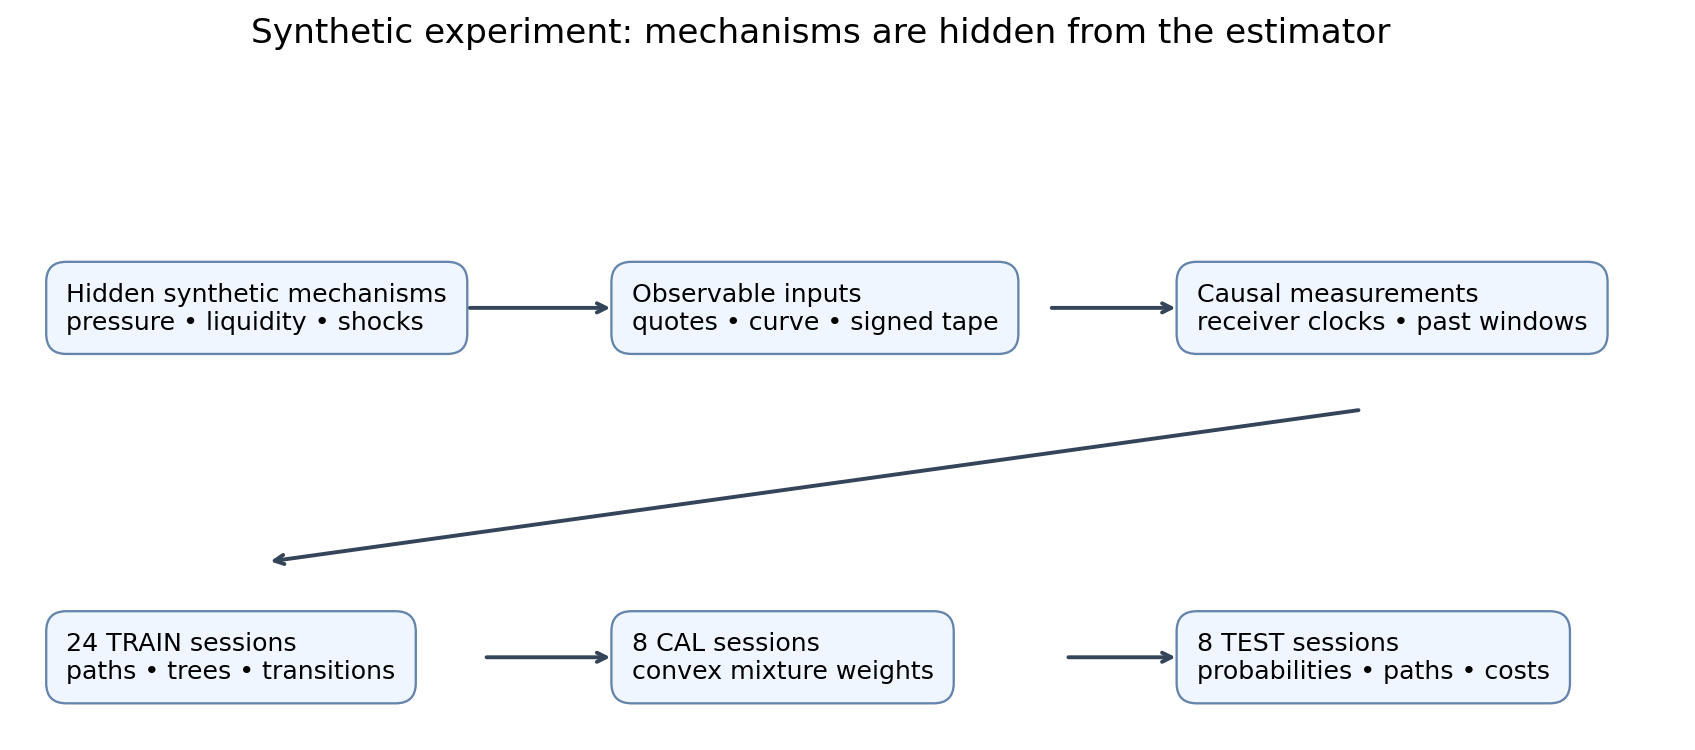

02-split.png


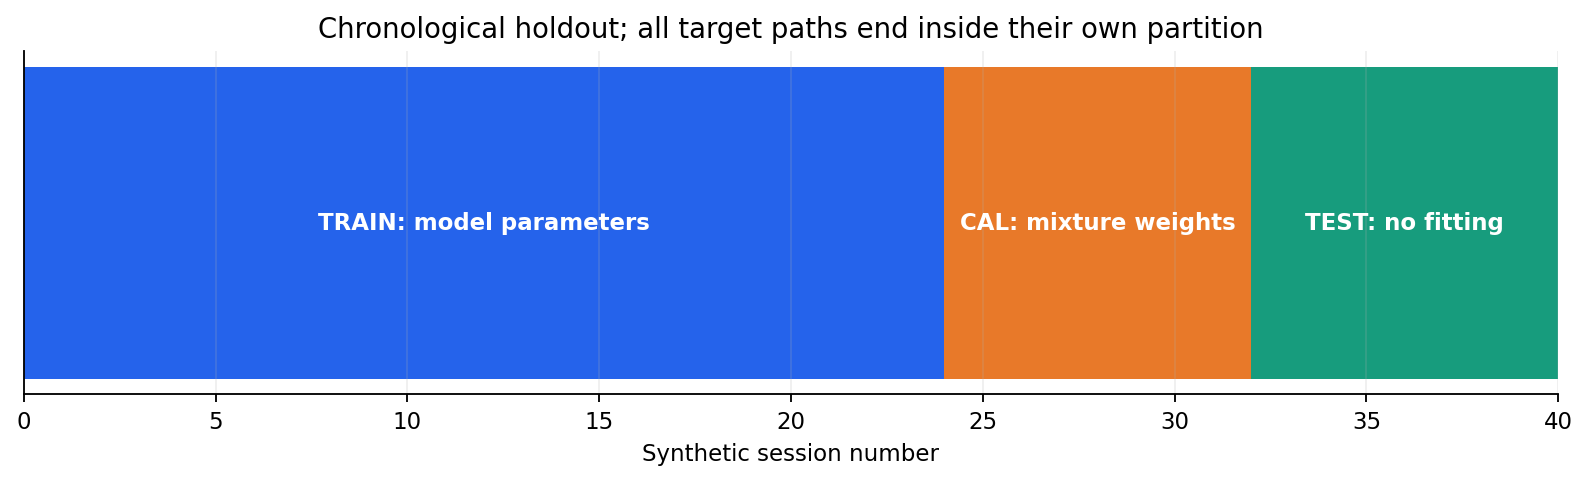

03-first-session.png


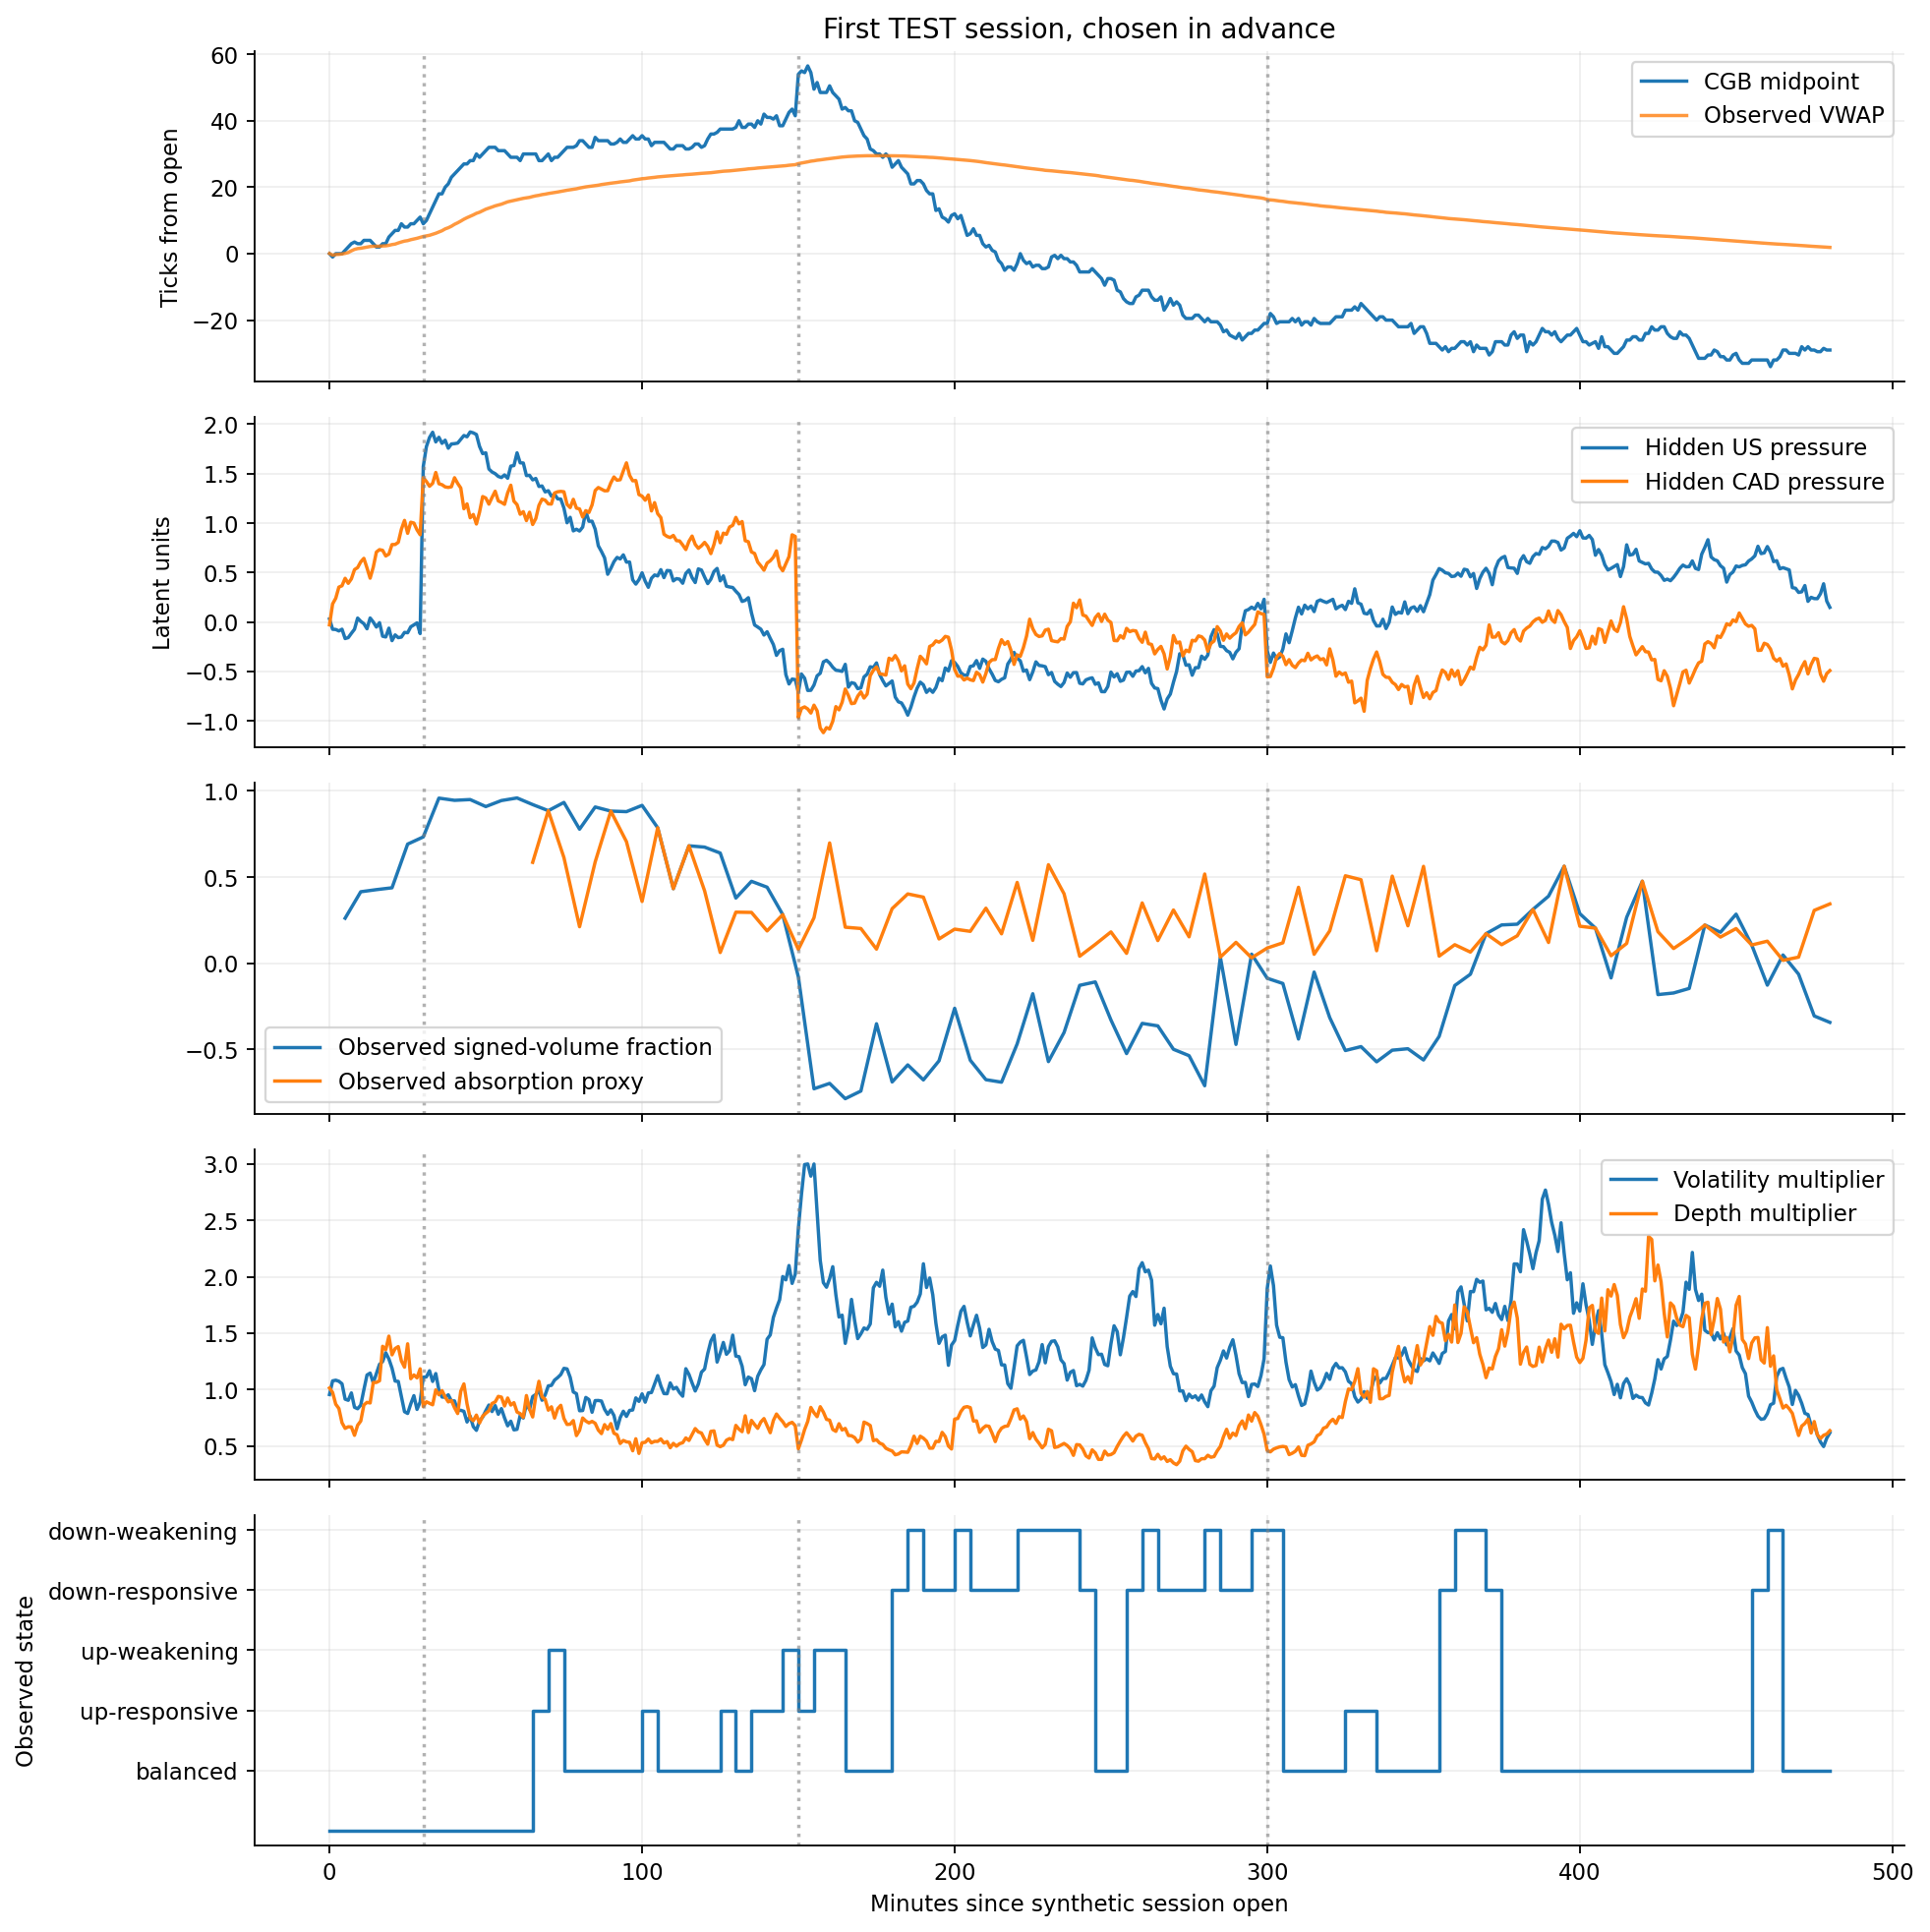

04-all-test-sessions.png


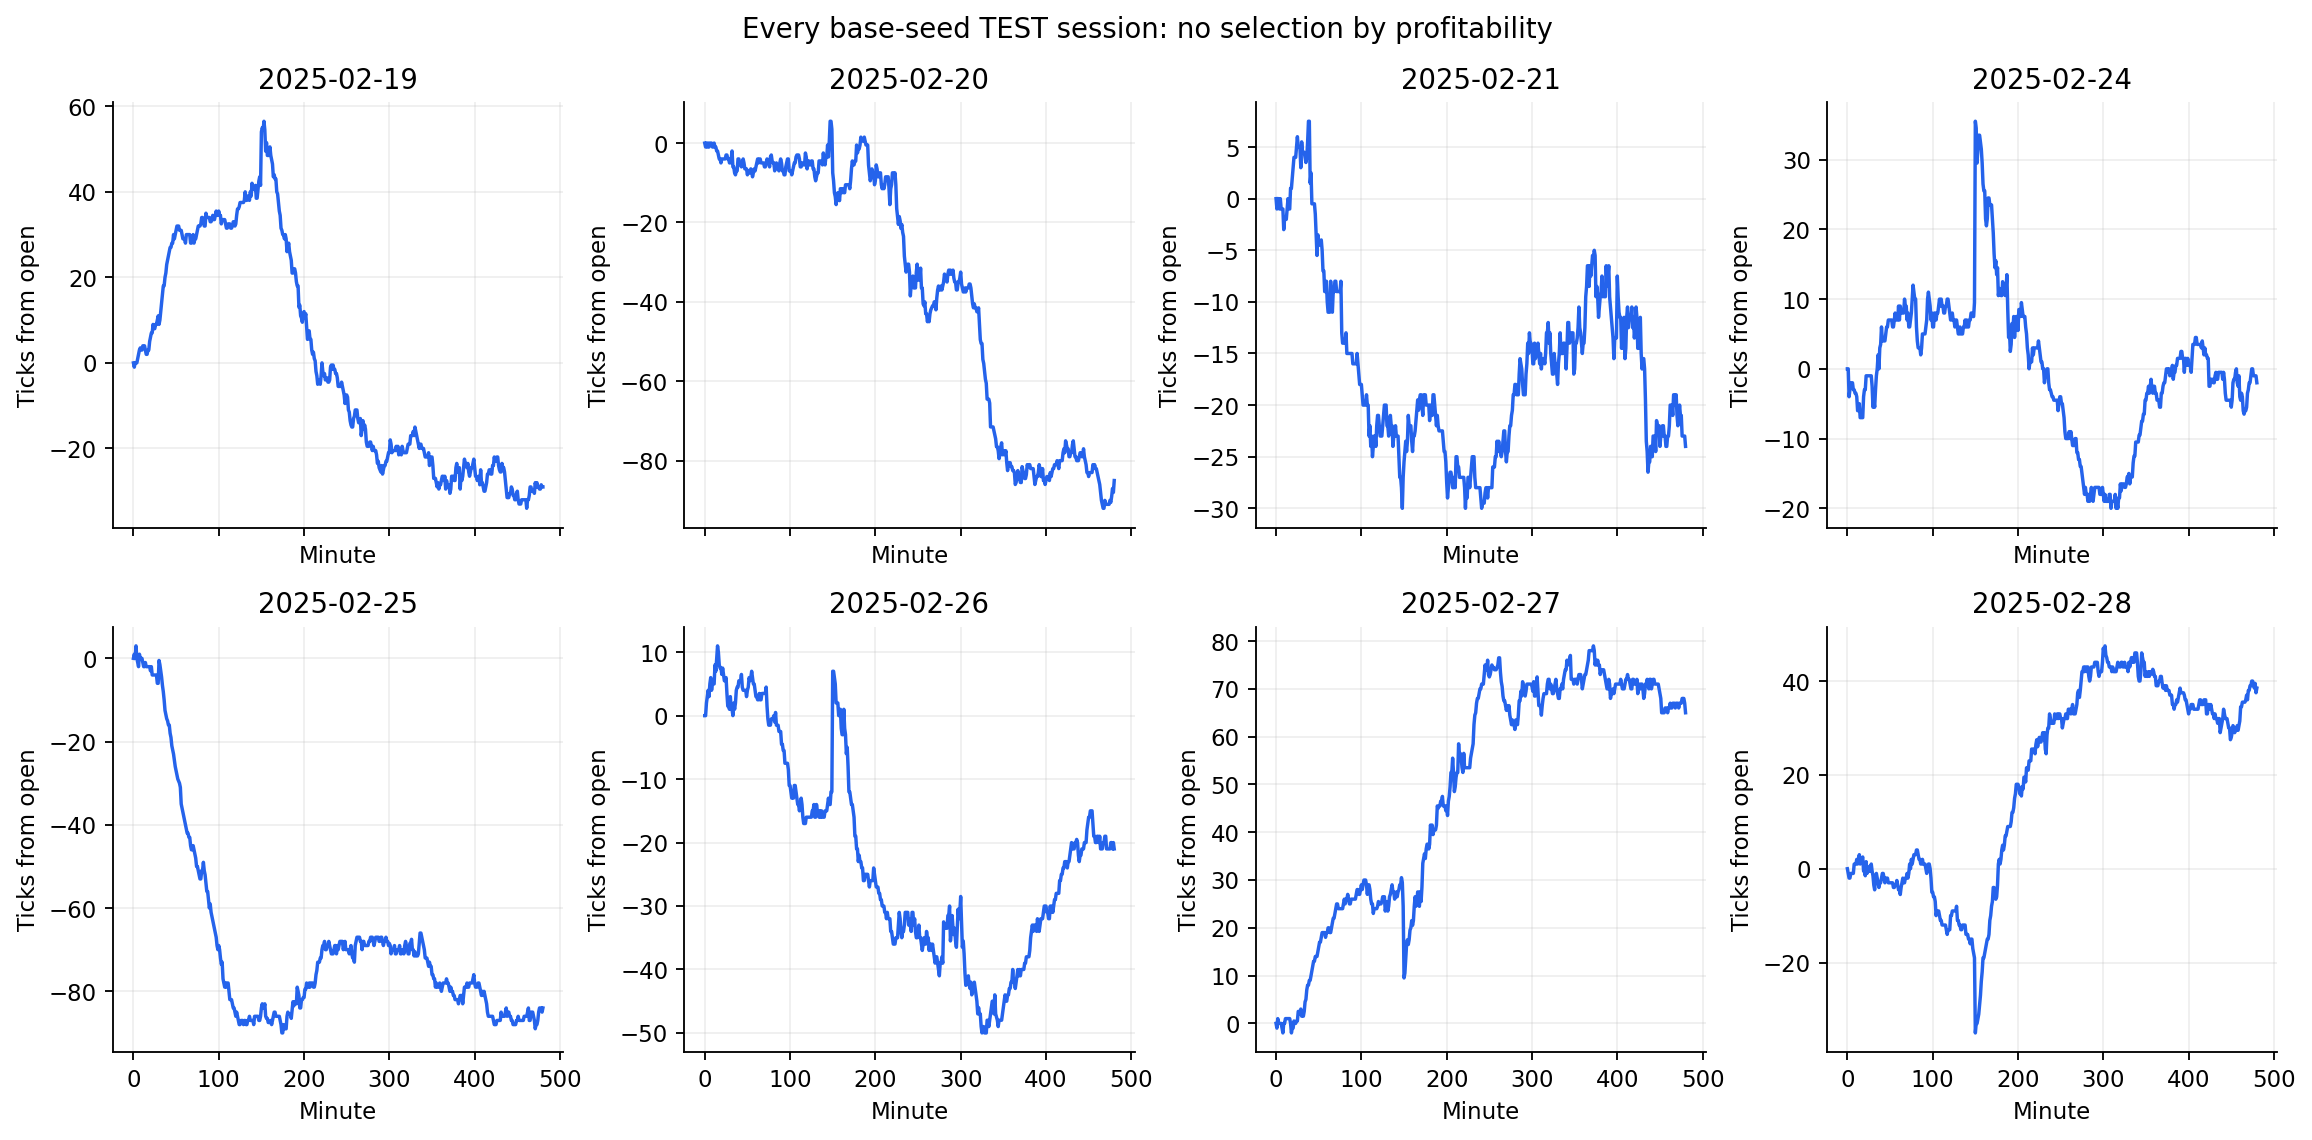

05-market-diagnostics.png


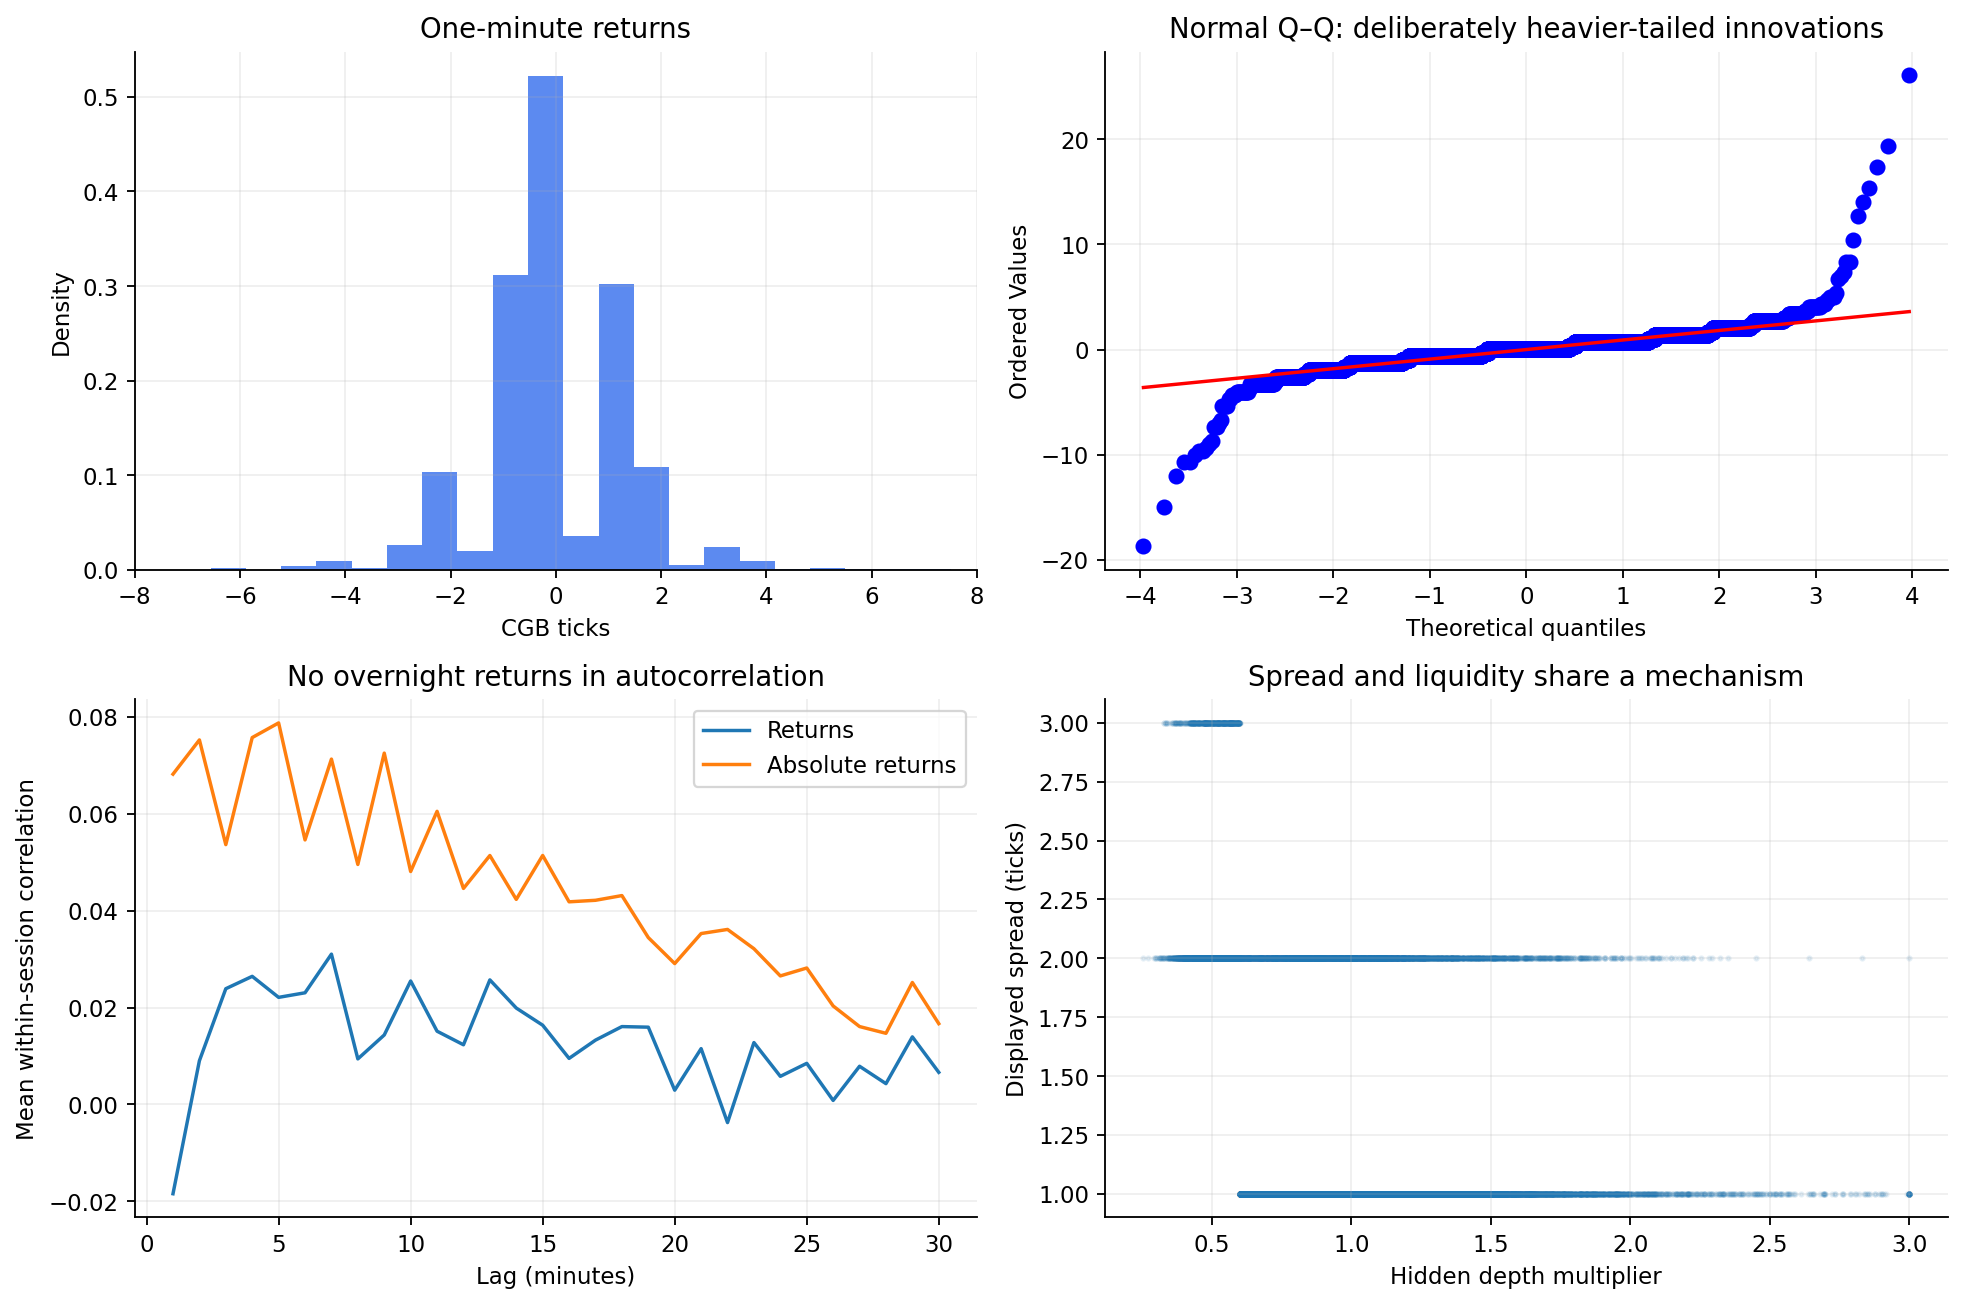

06-feature-correlation.png


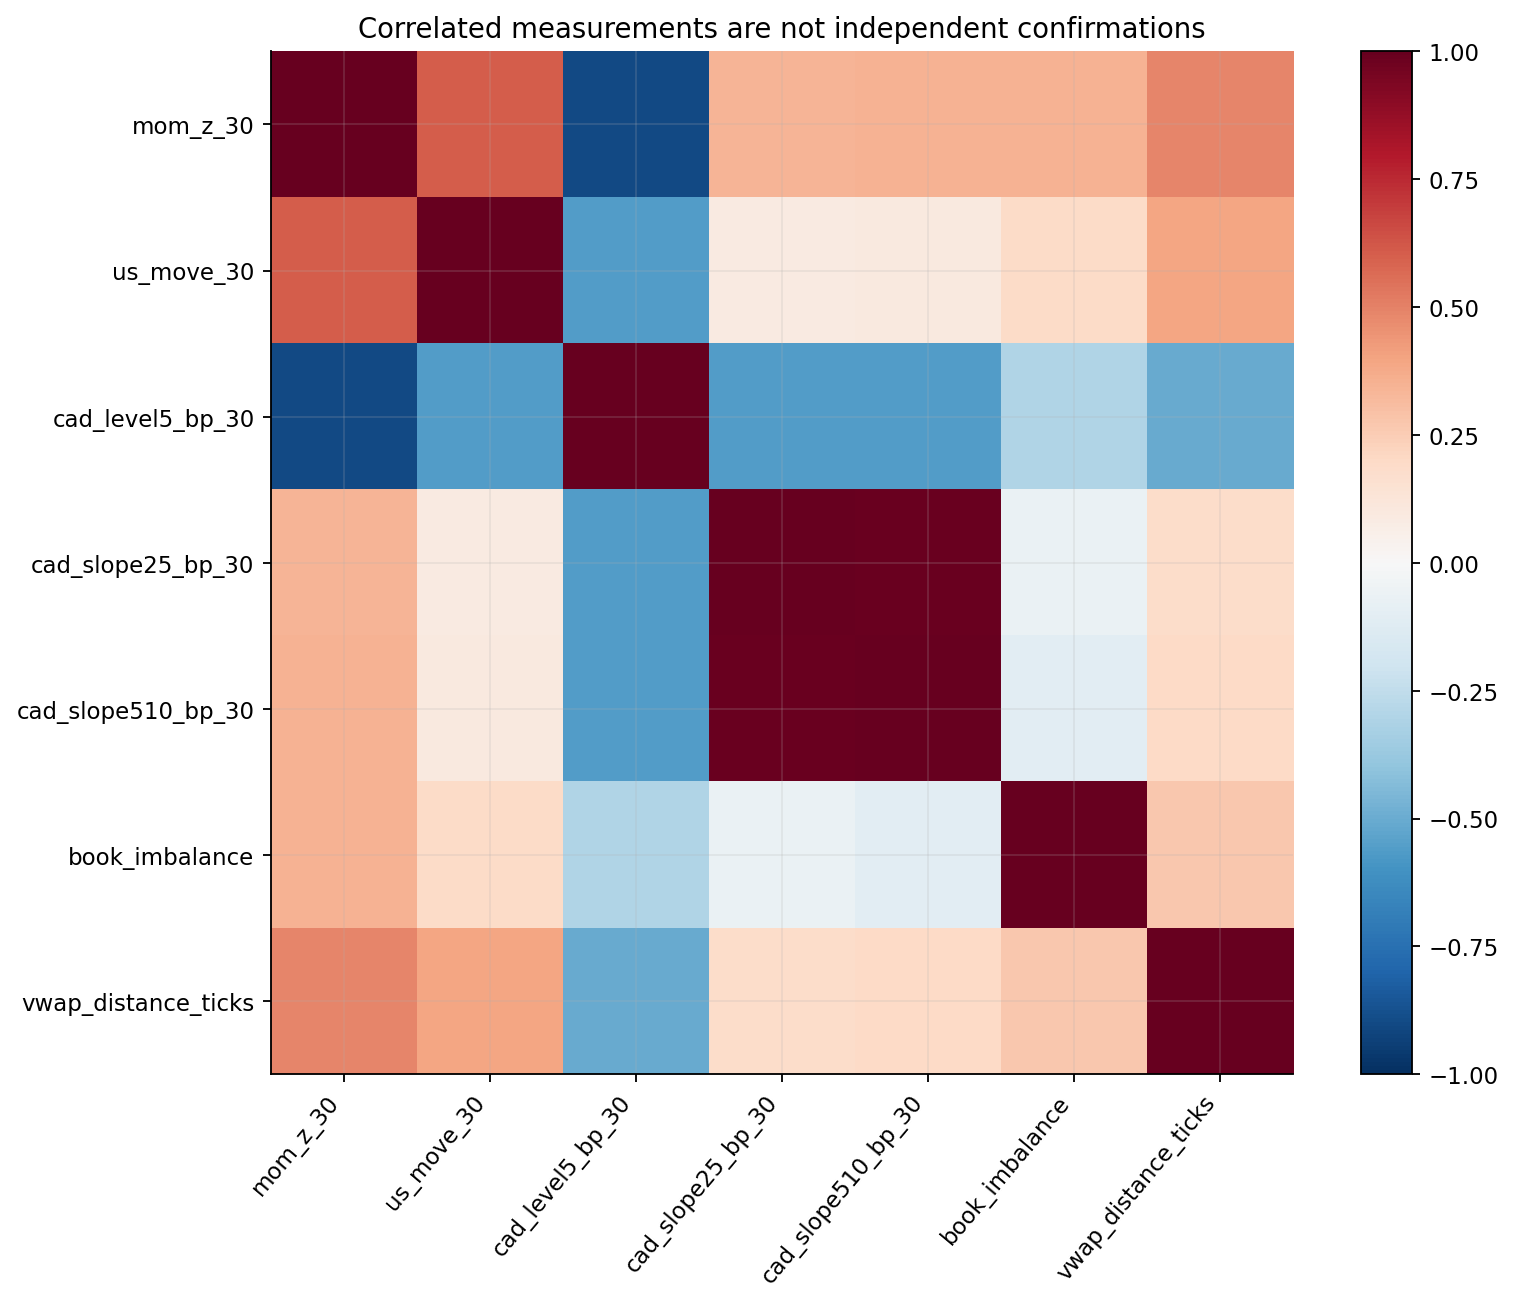

In [6]:
for number in range(1, 7):
    path = next((ROOT / 'figures').glob(f'{number:02d}-*.png'))
    print(path.name)
    display(Image(filename=str(path)))

## Model probabilities, calibration and paths

07-transitions.png


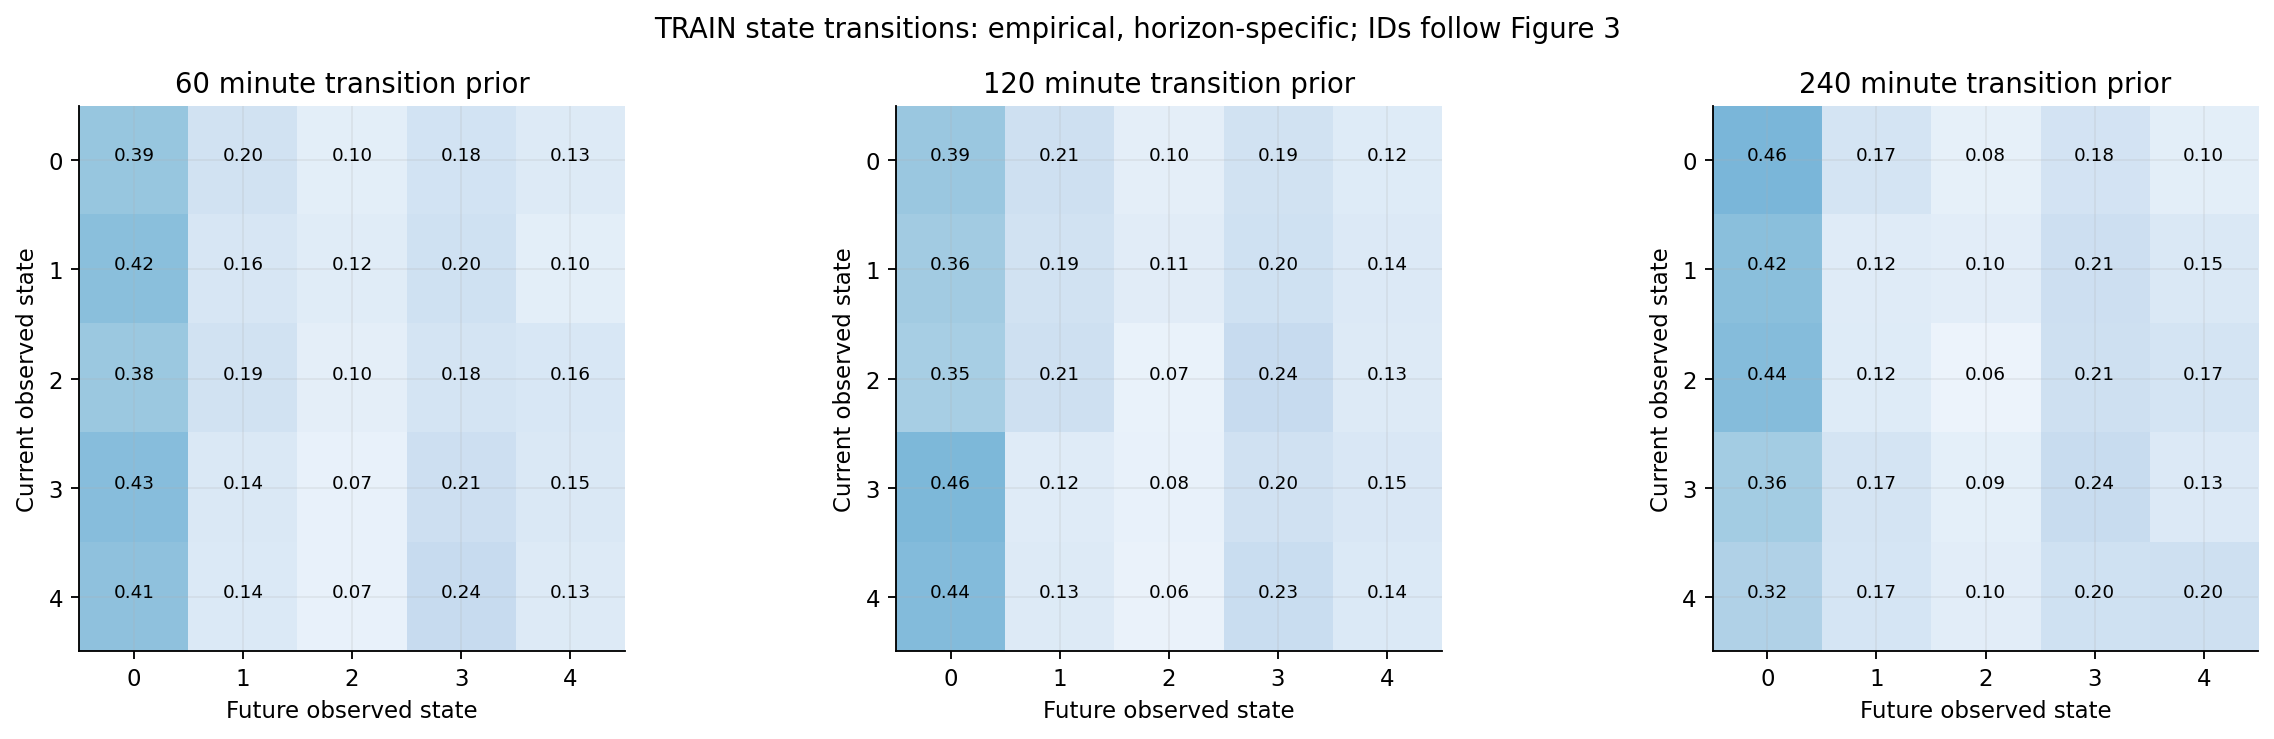

08-calibration-weights.png


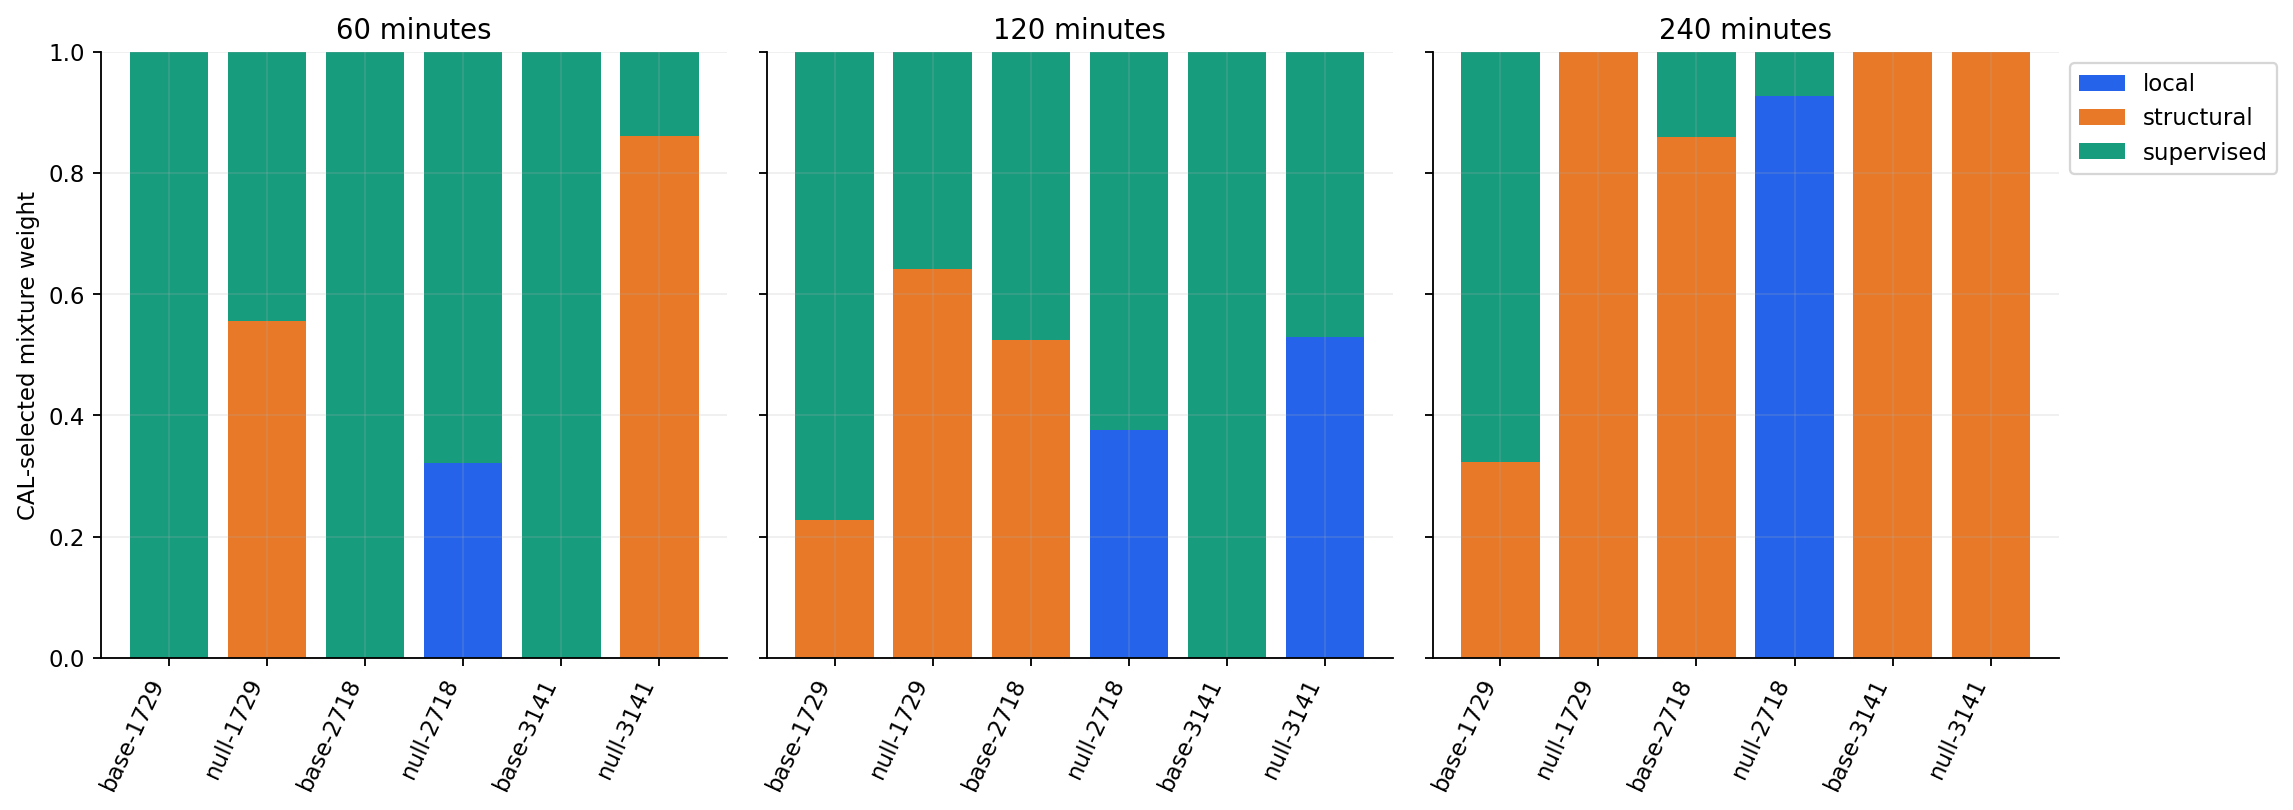

09-forecast-loss.png


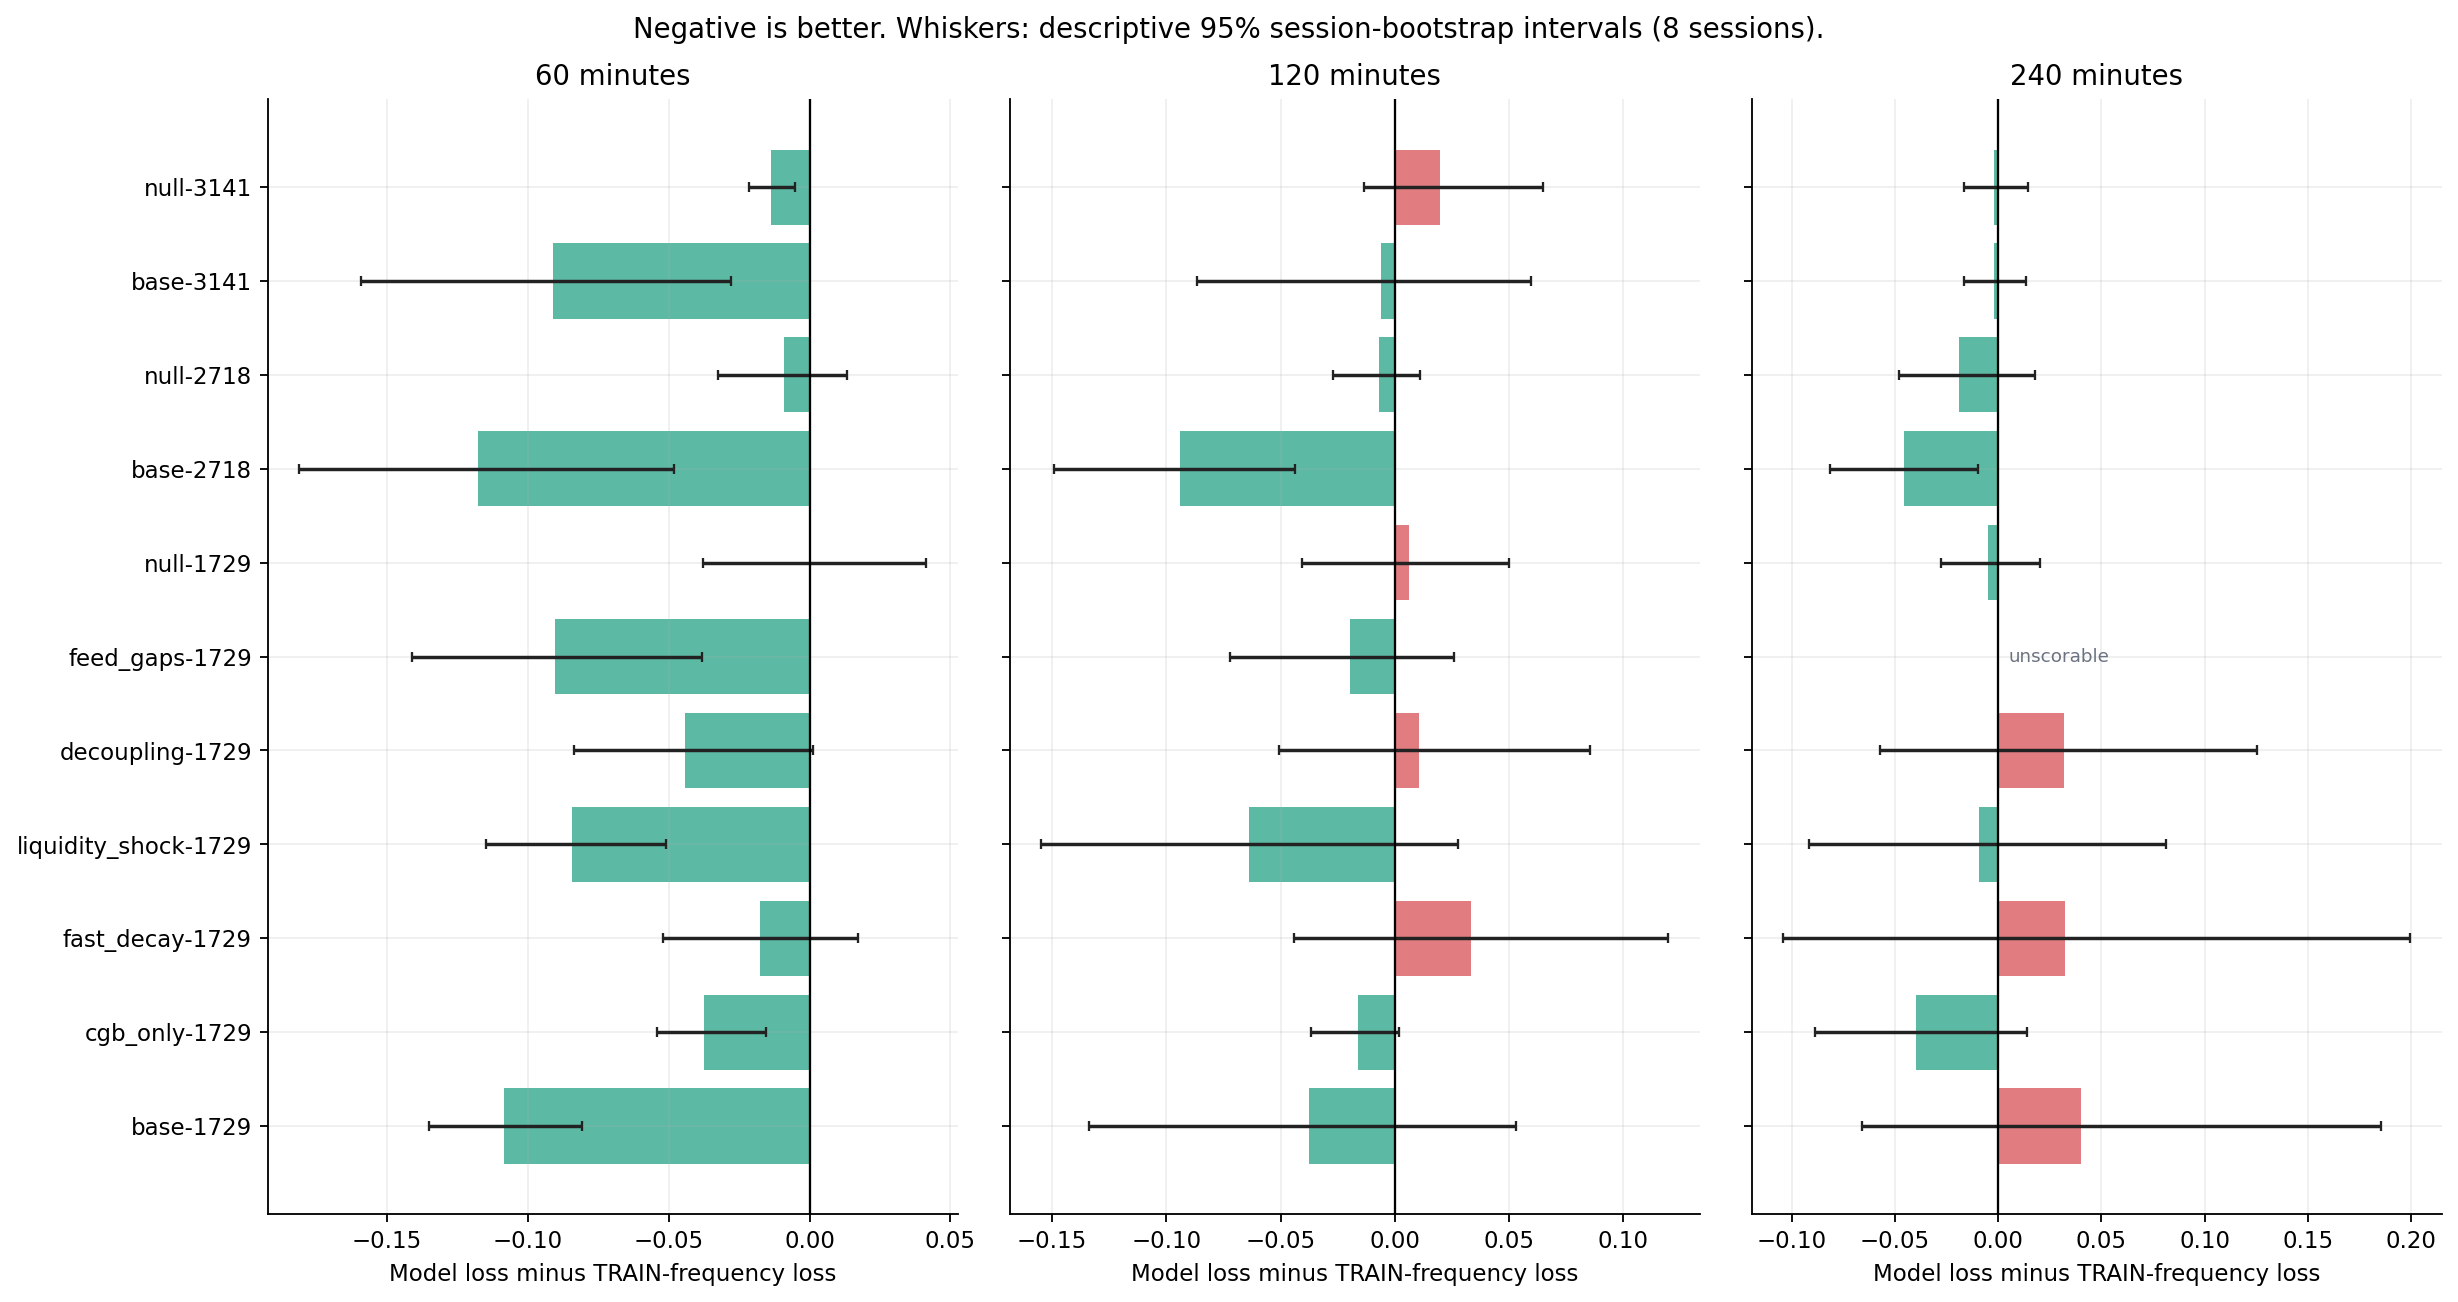

10-reliability.png


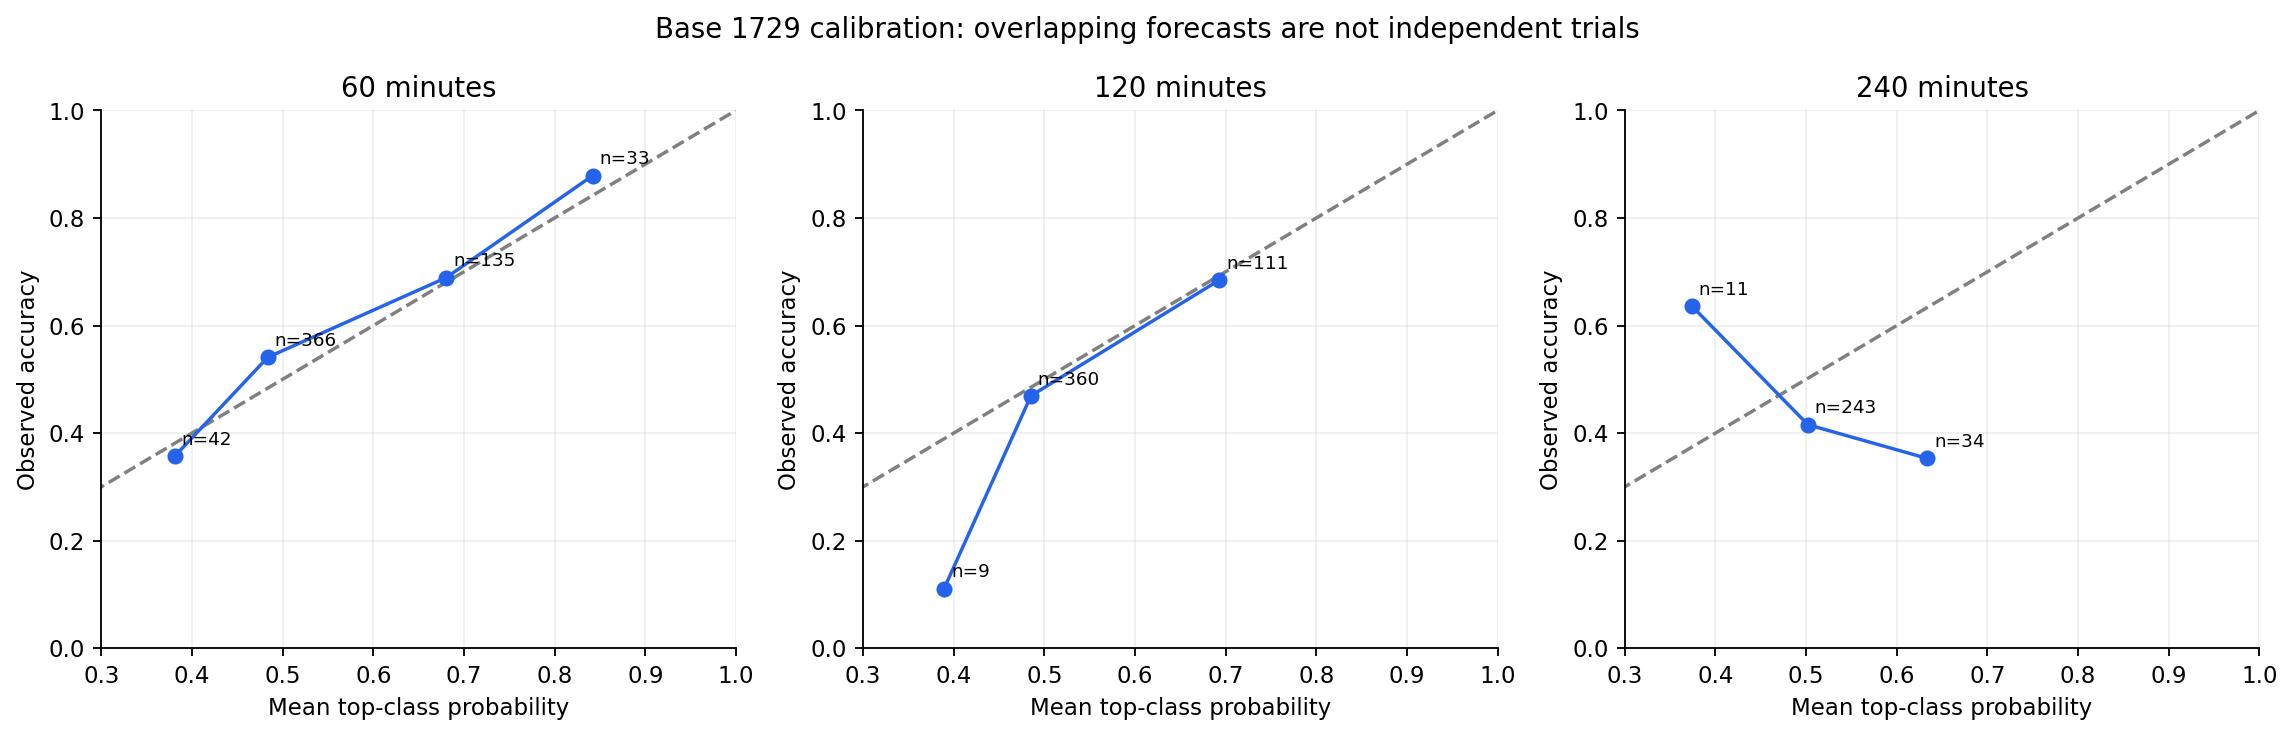

11-interval-coverage.png


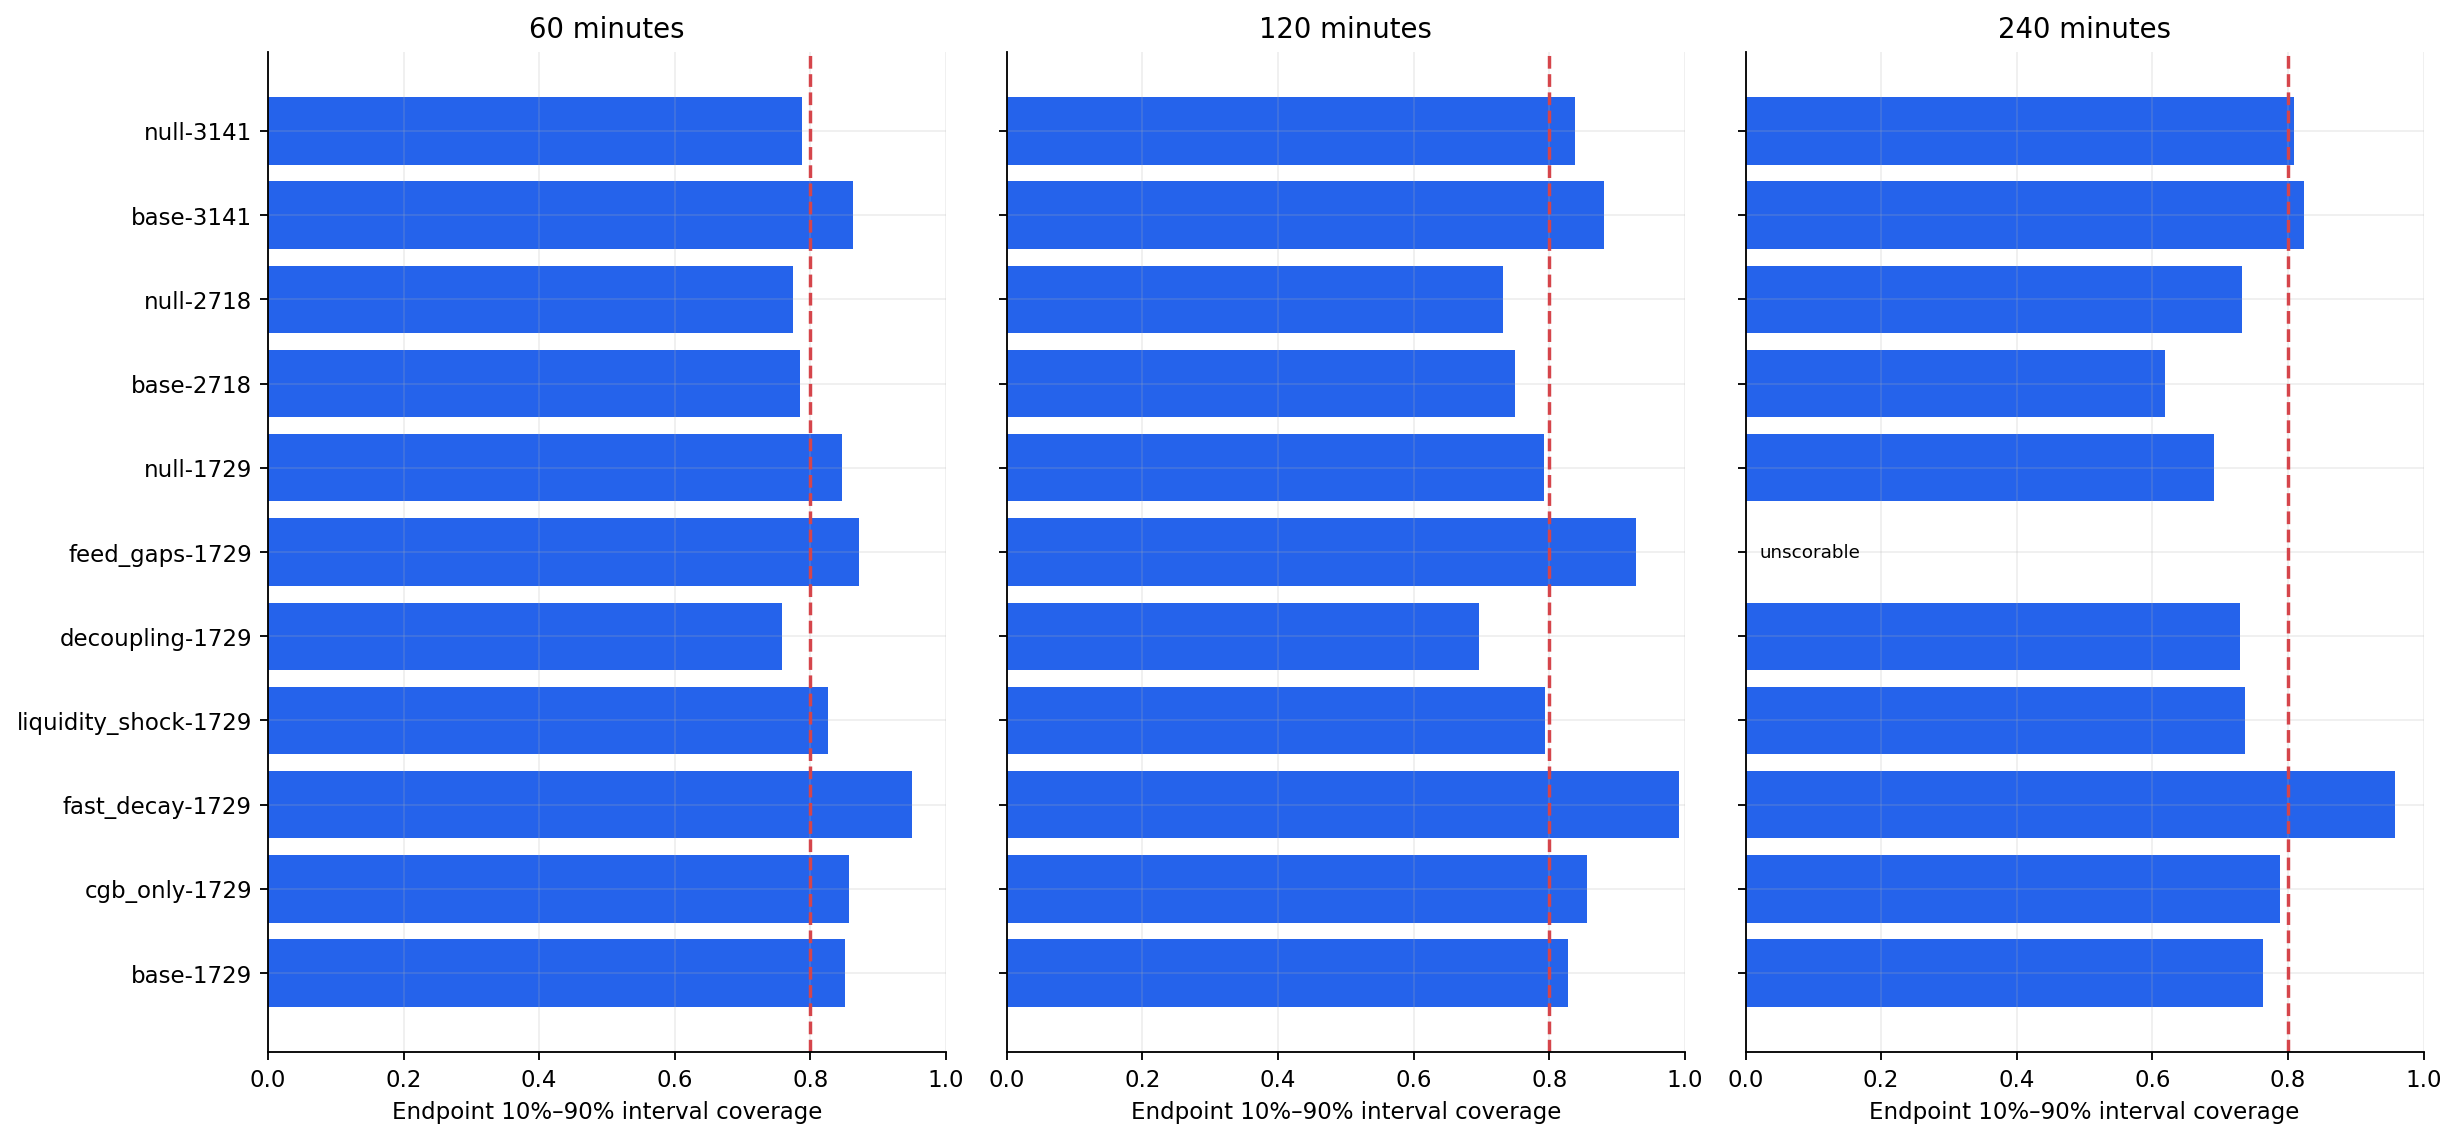

12-endpoint-forecast.png


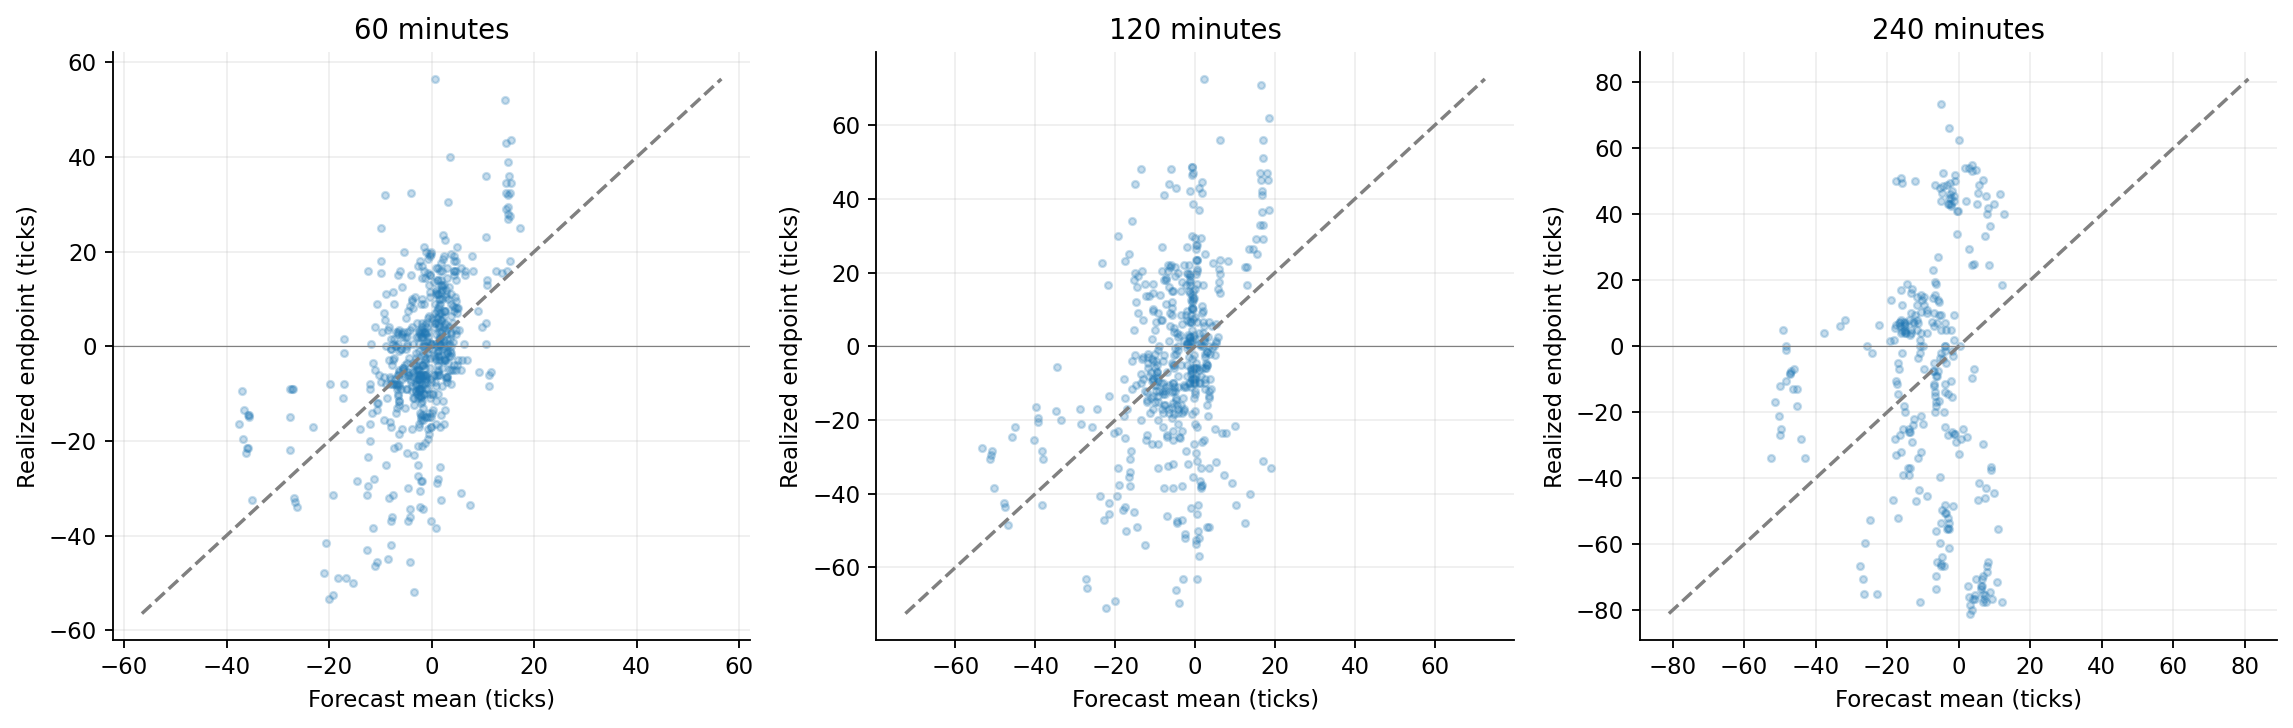

13-path-risk.png


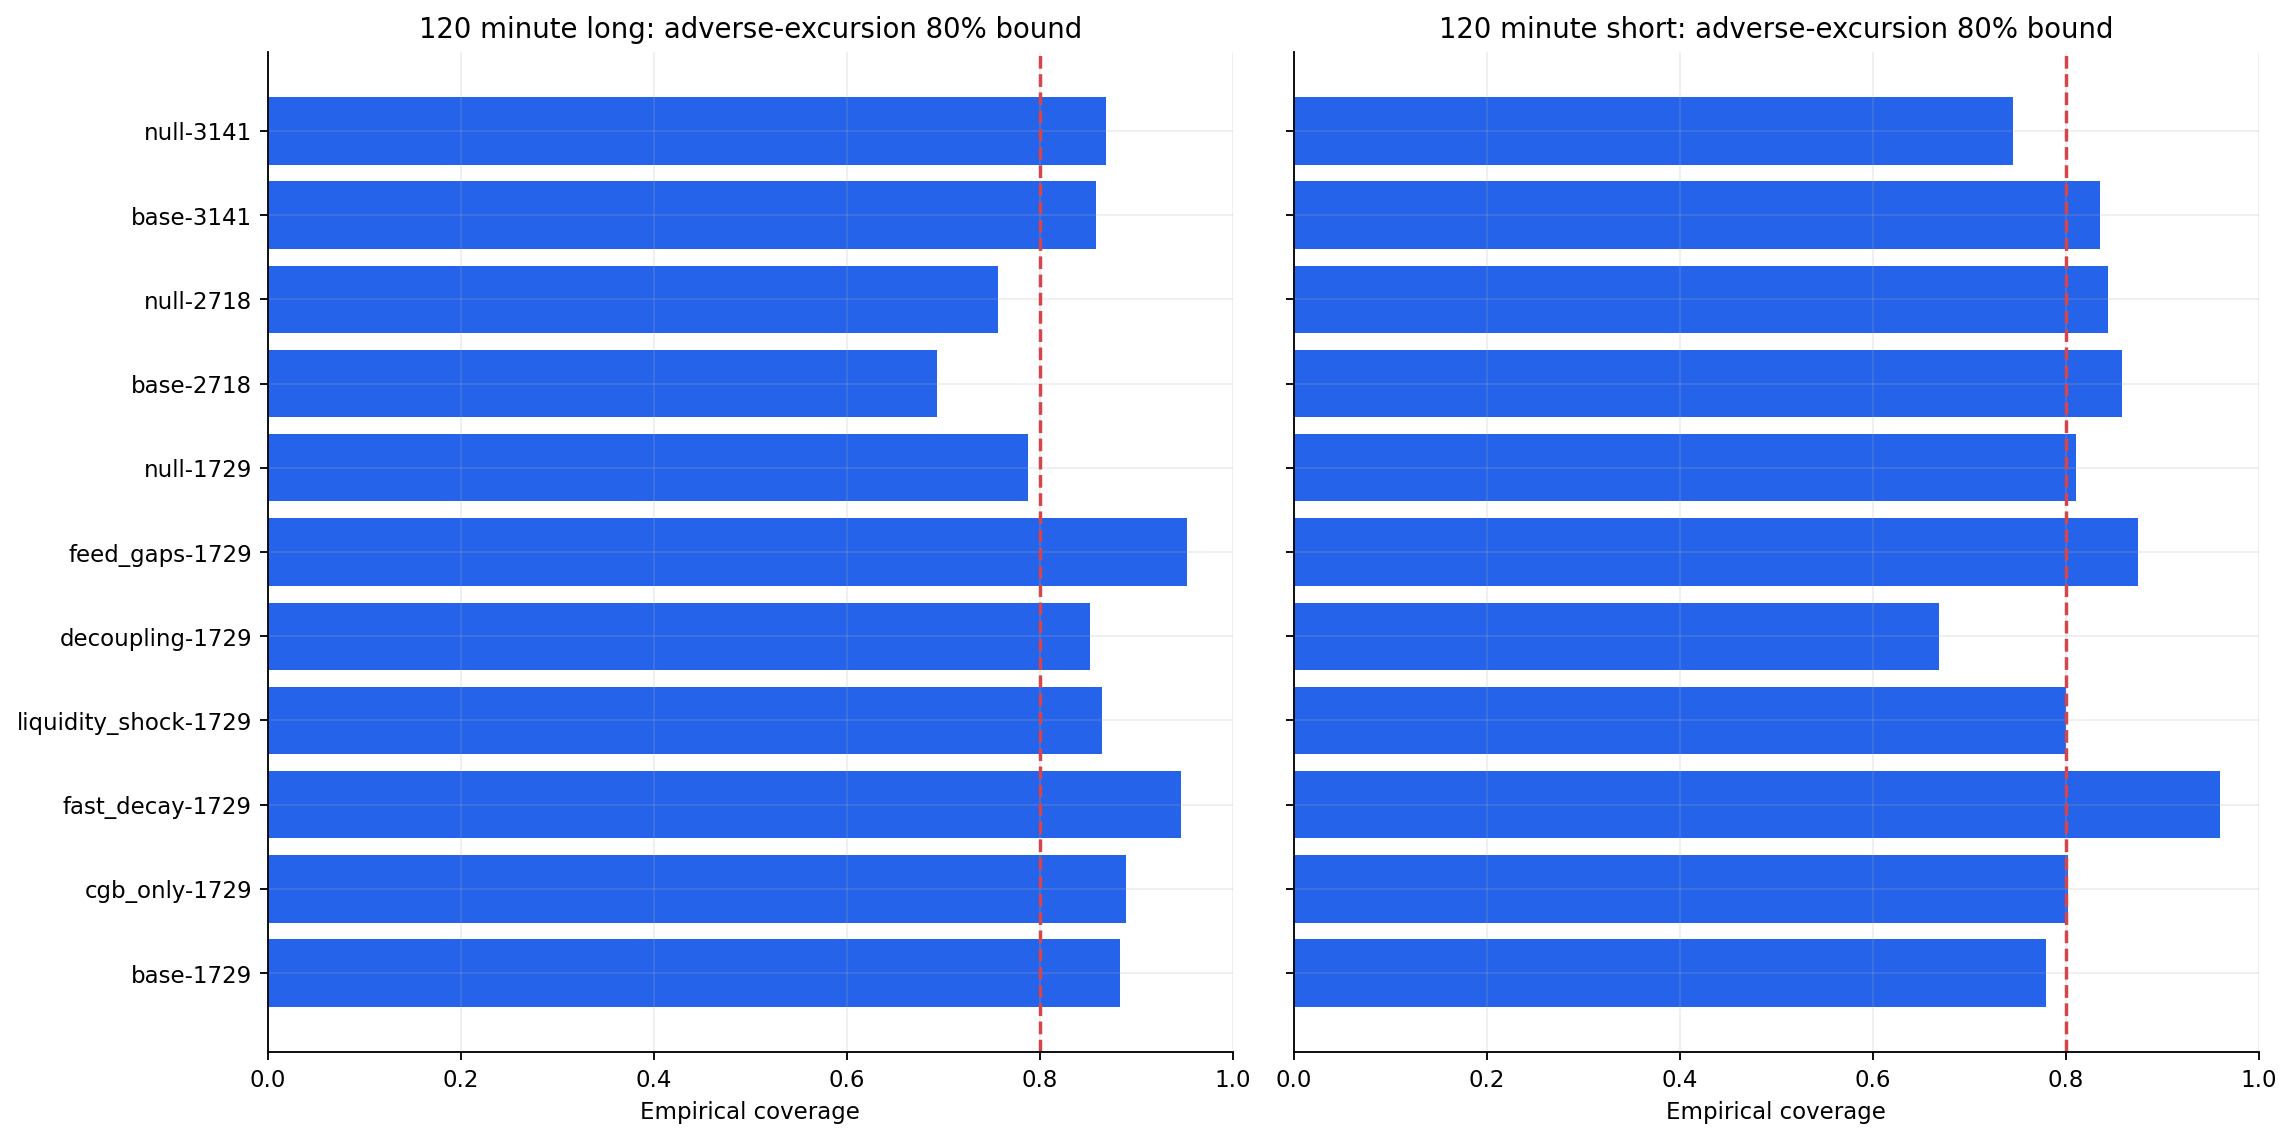

14-path-fans.png


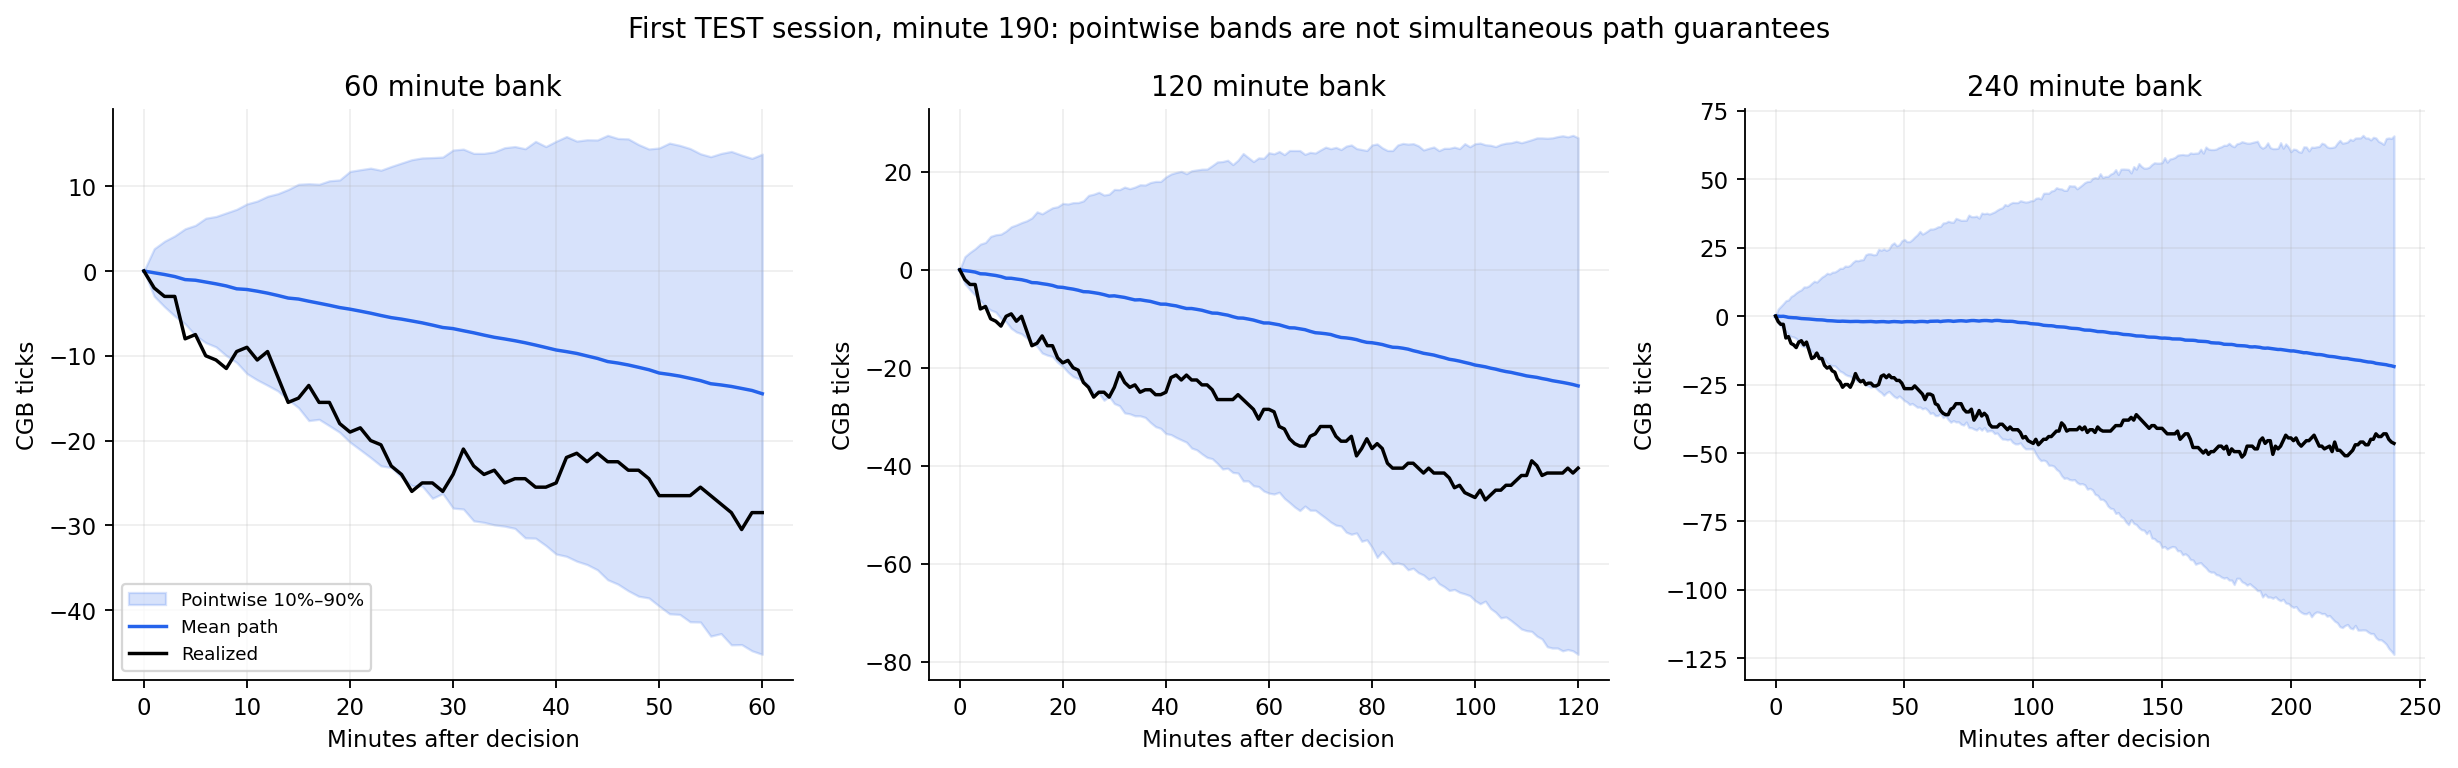

In [7]:
for number in range(7, 15):
    path = next((ROOT / 'figures').glob(f'{number:02d}-*.png'))
    print(path.name)
    display(Image(filename=str(path)))

## Execution, failures and the supplied example

15-execution-stress.png


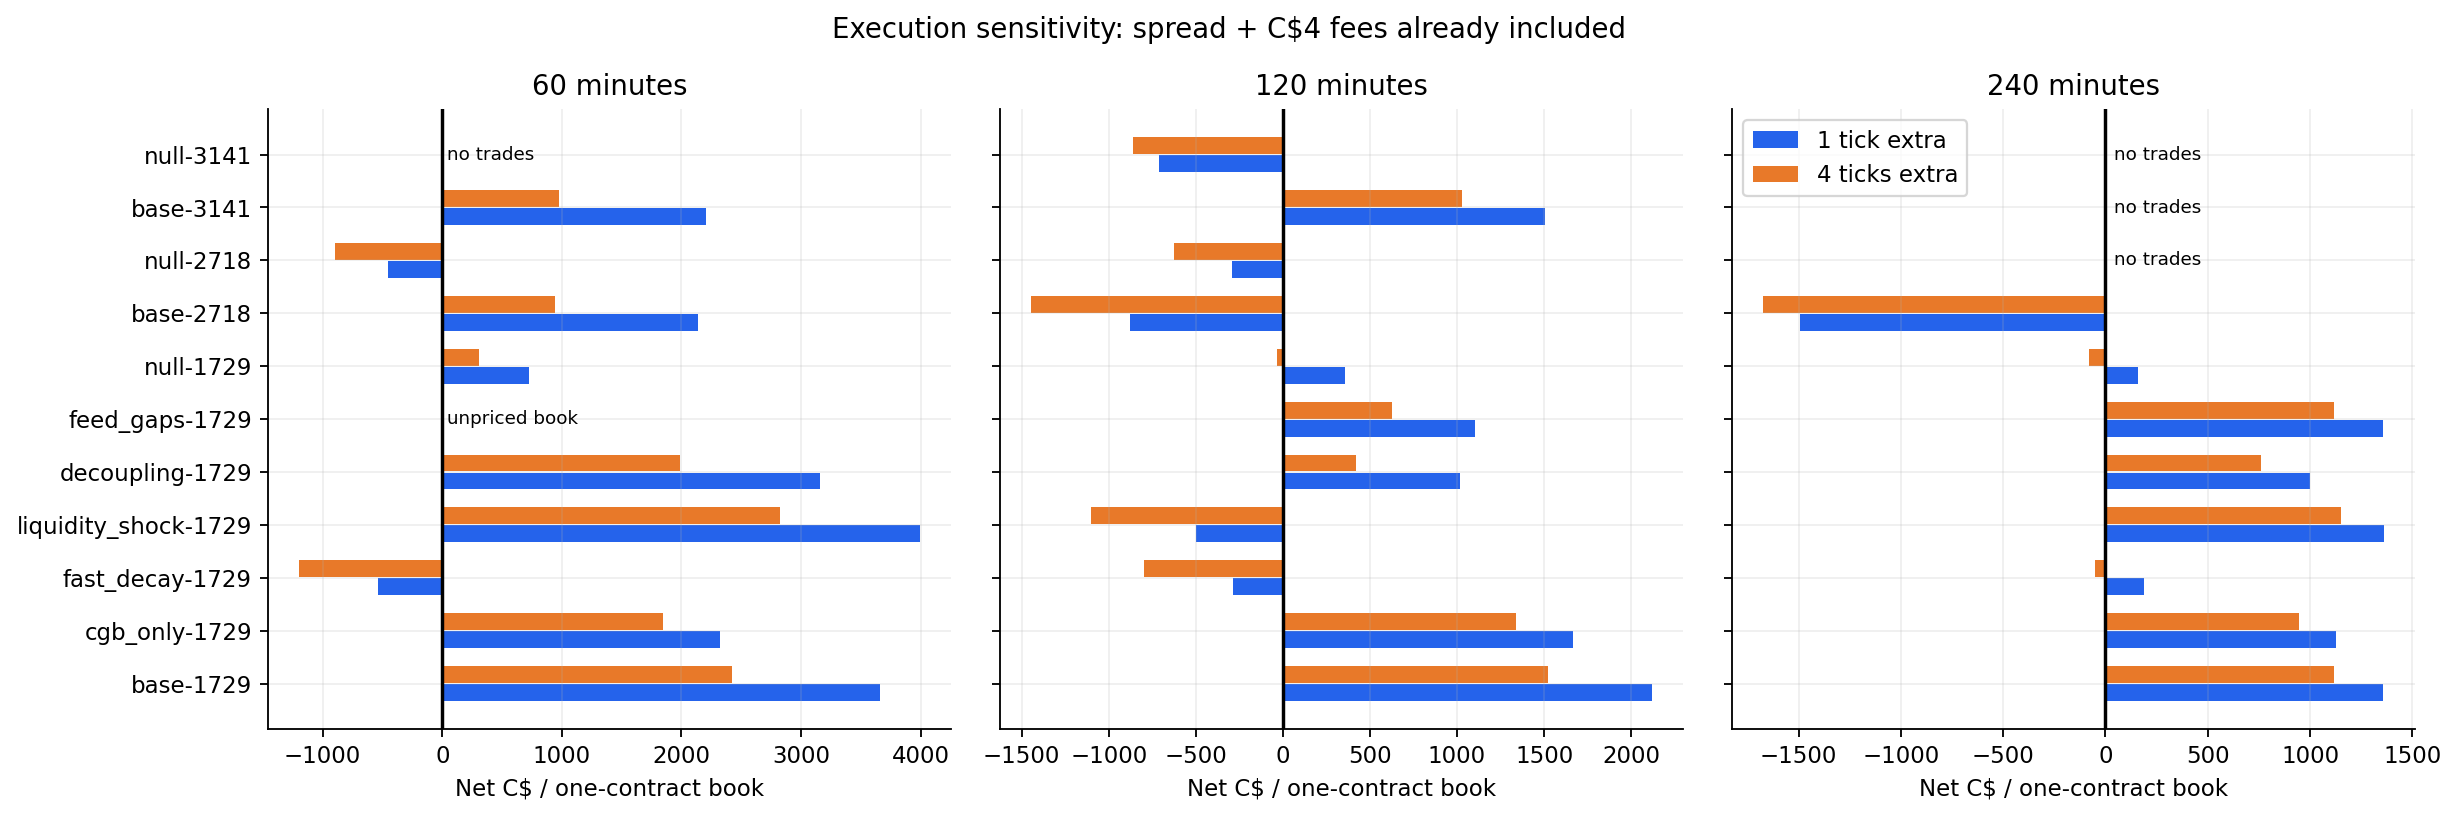

16-marked-pnl.png


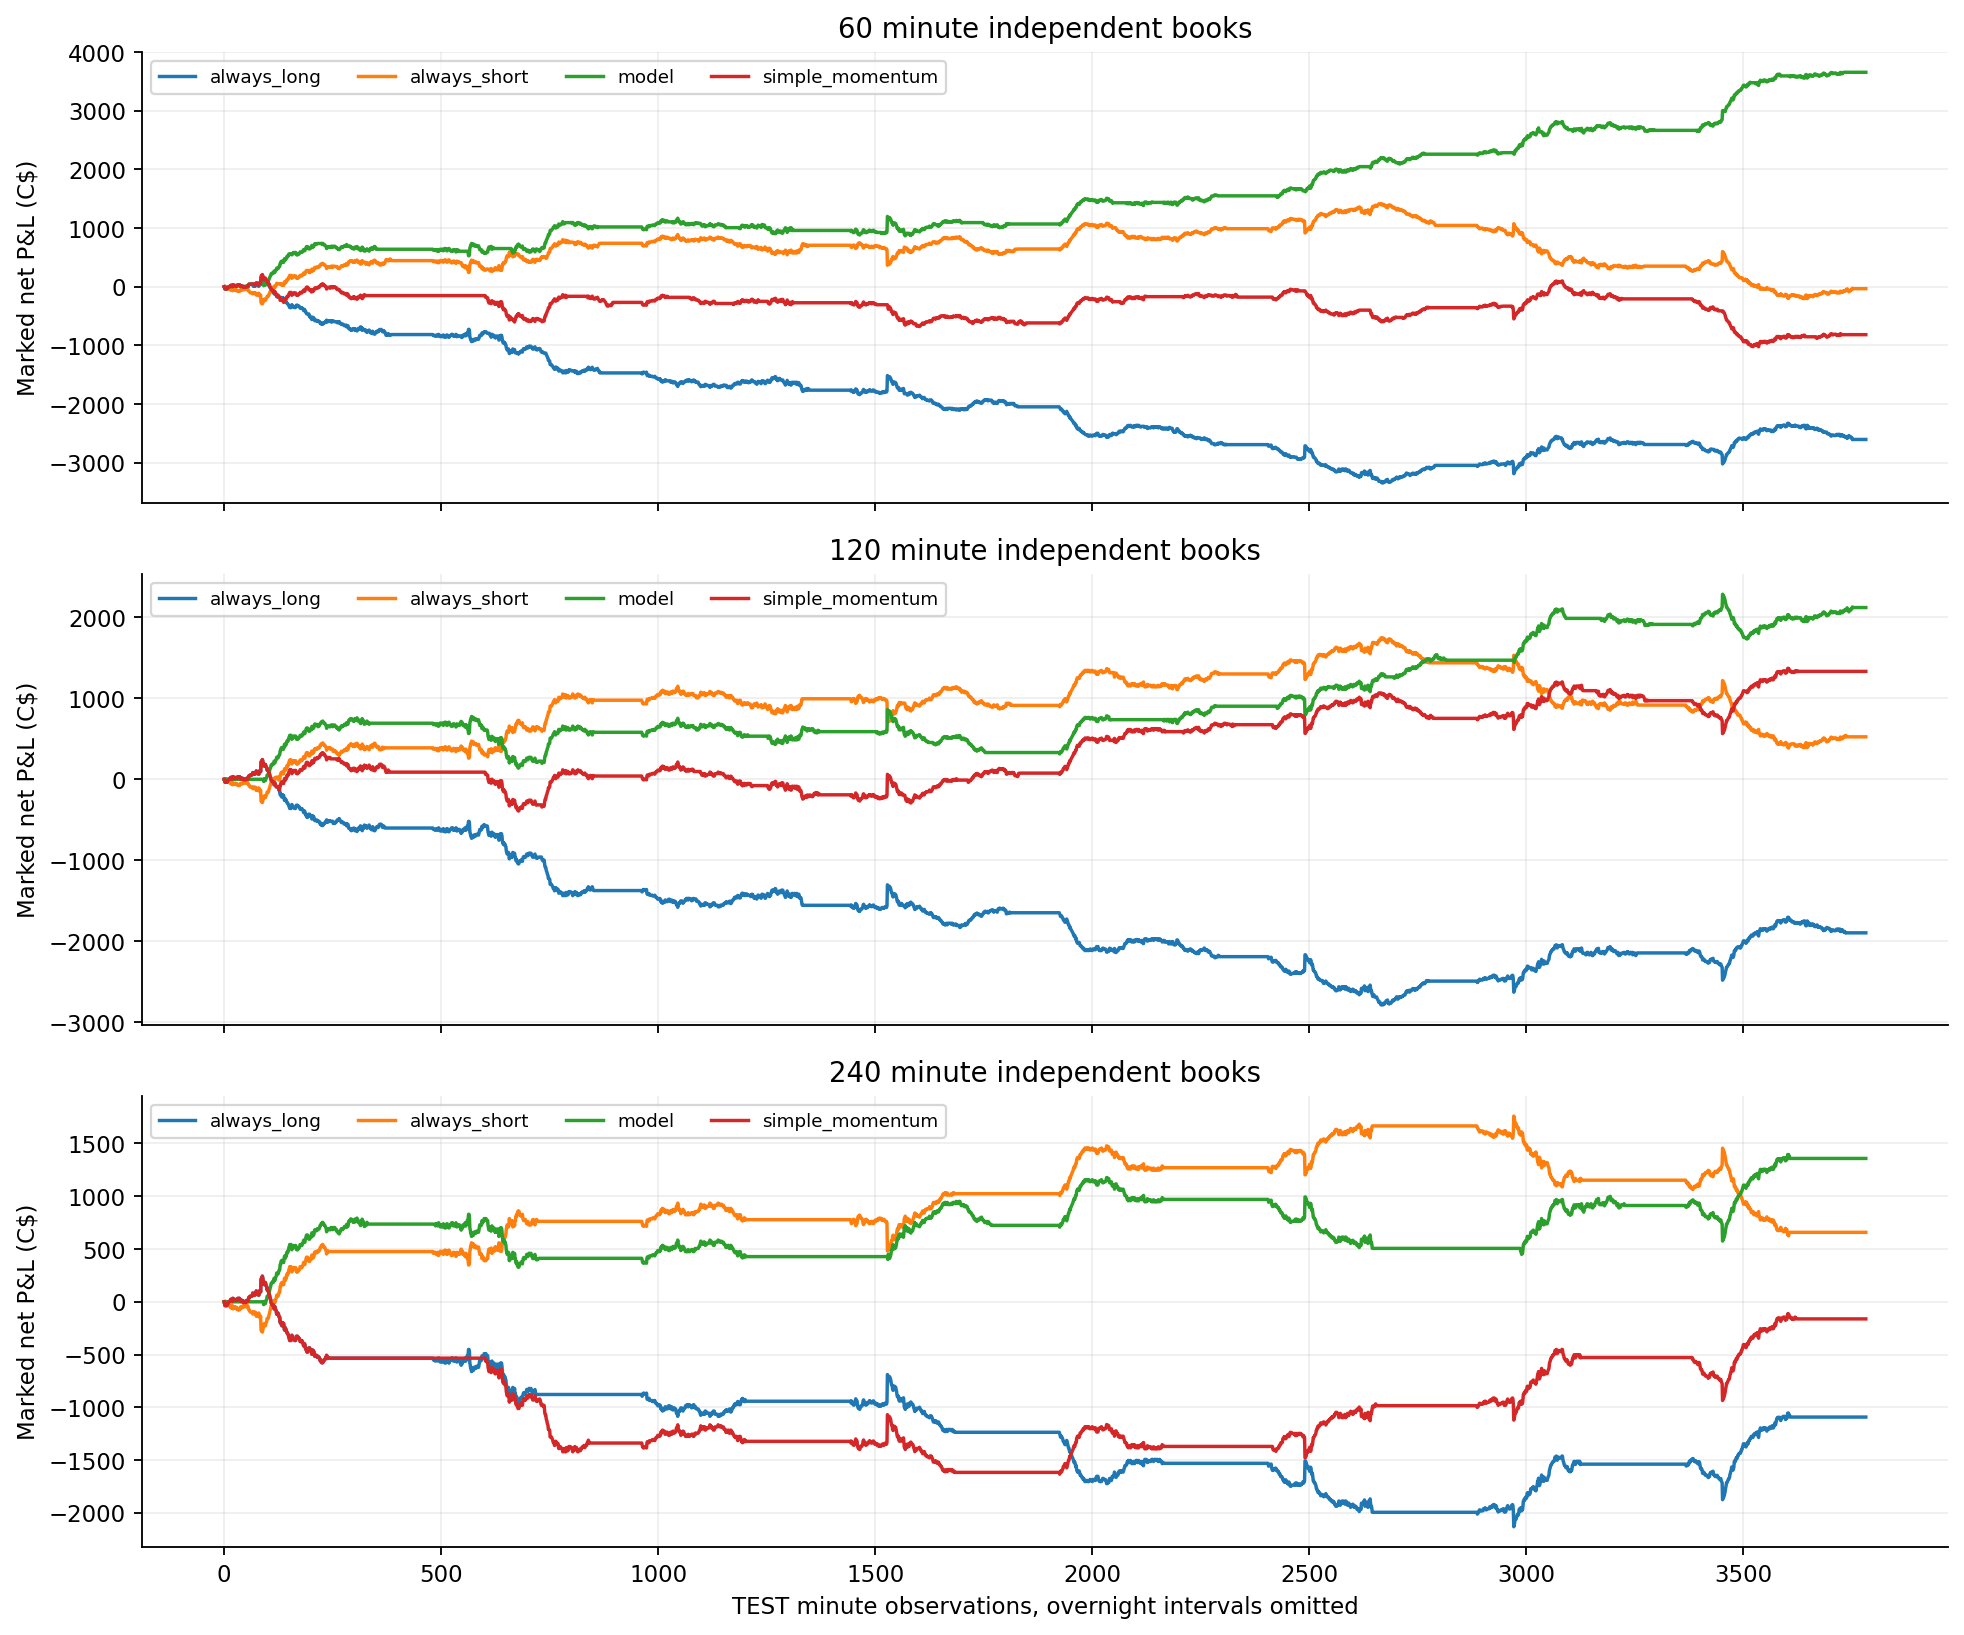

17-support.png


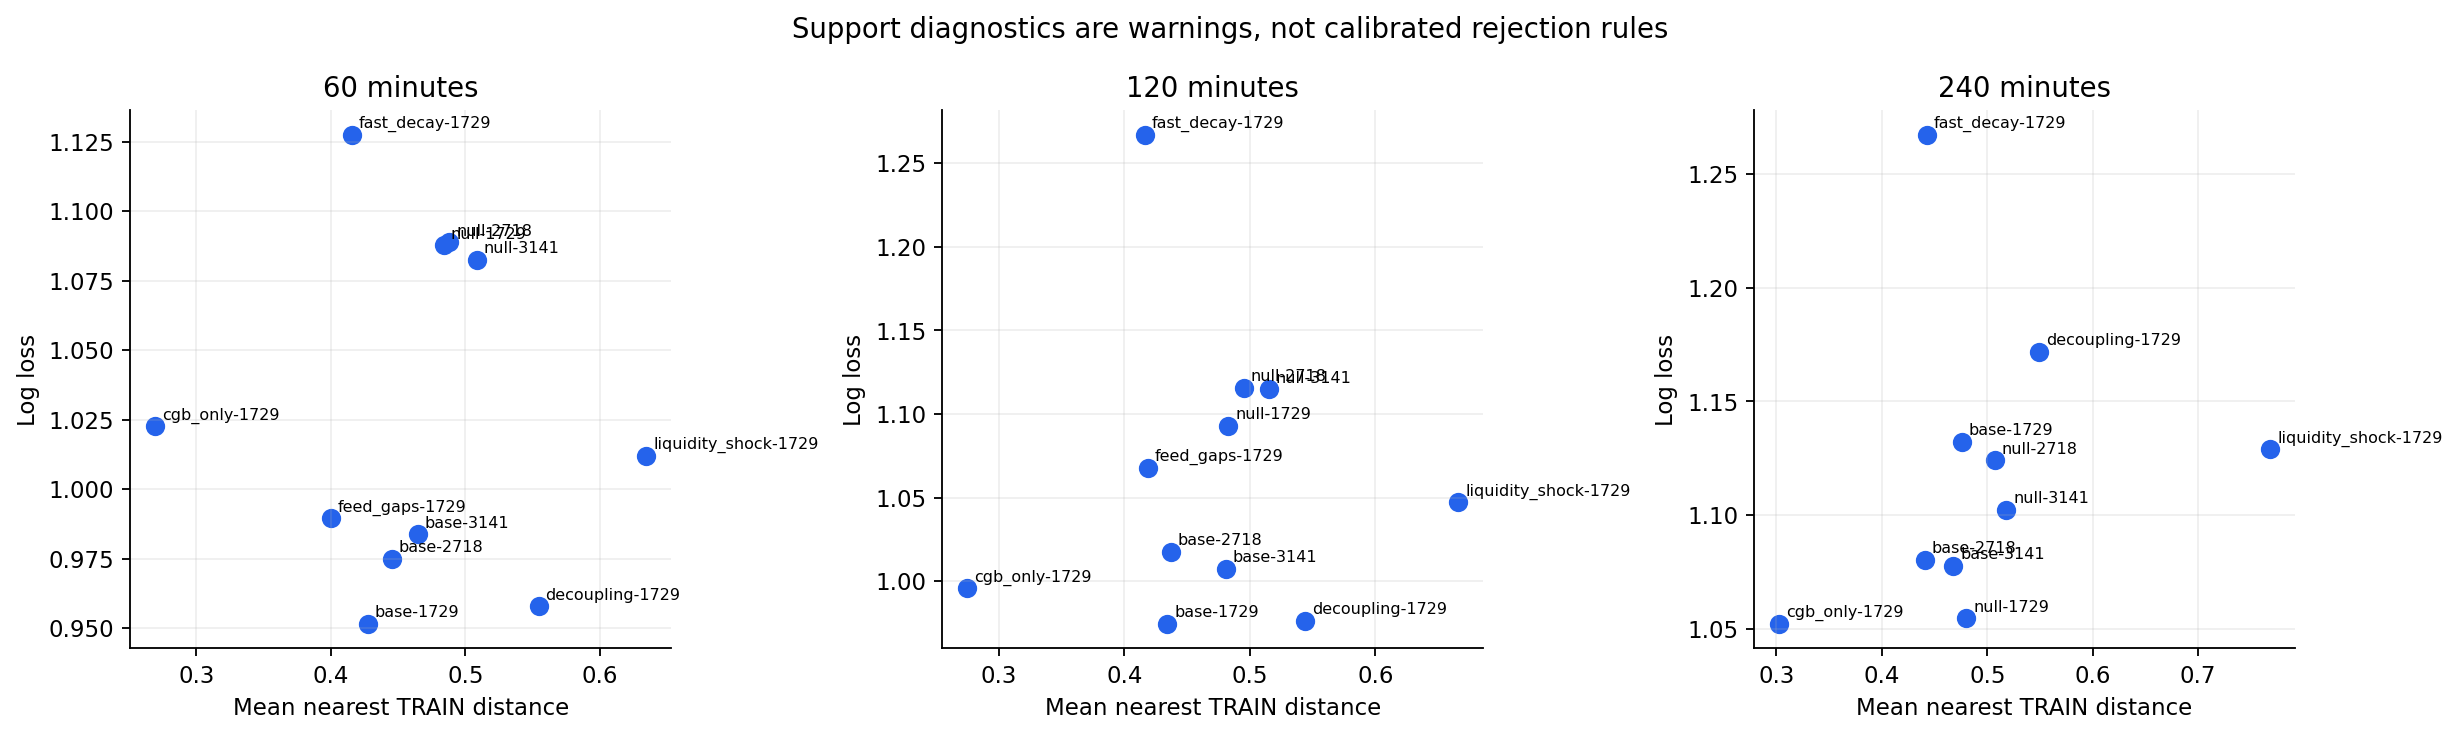

18-data-availability.png


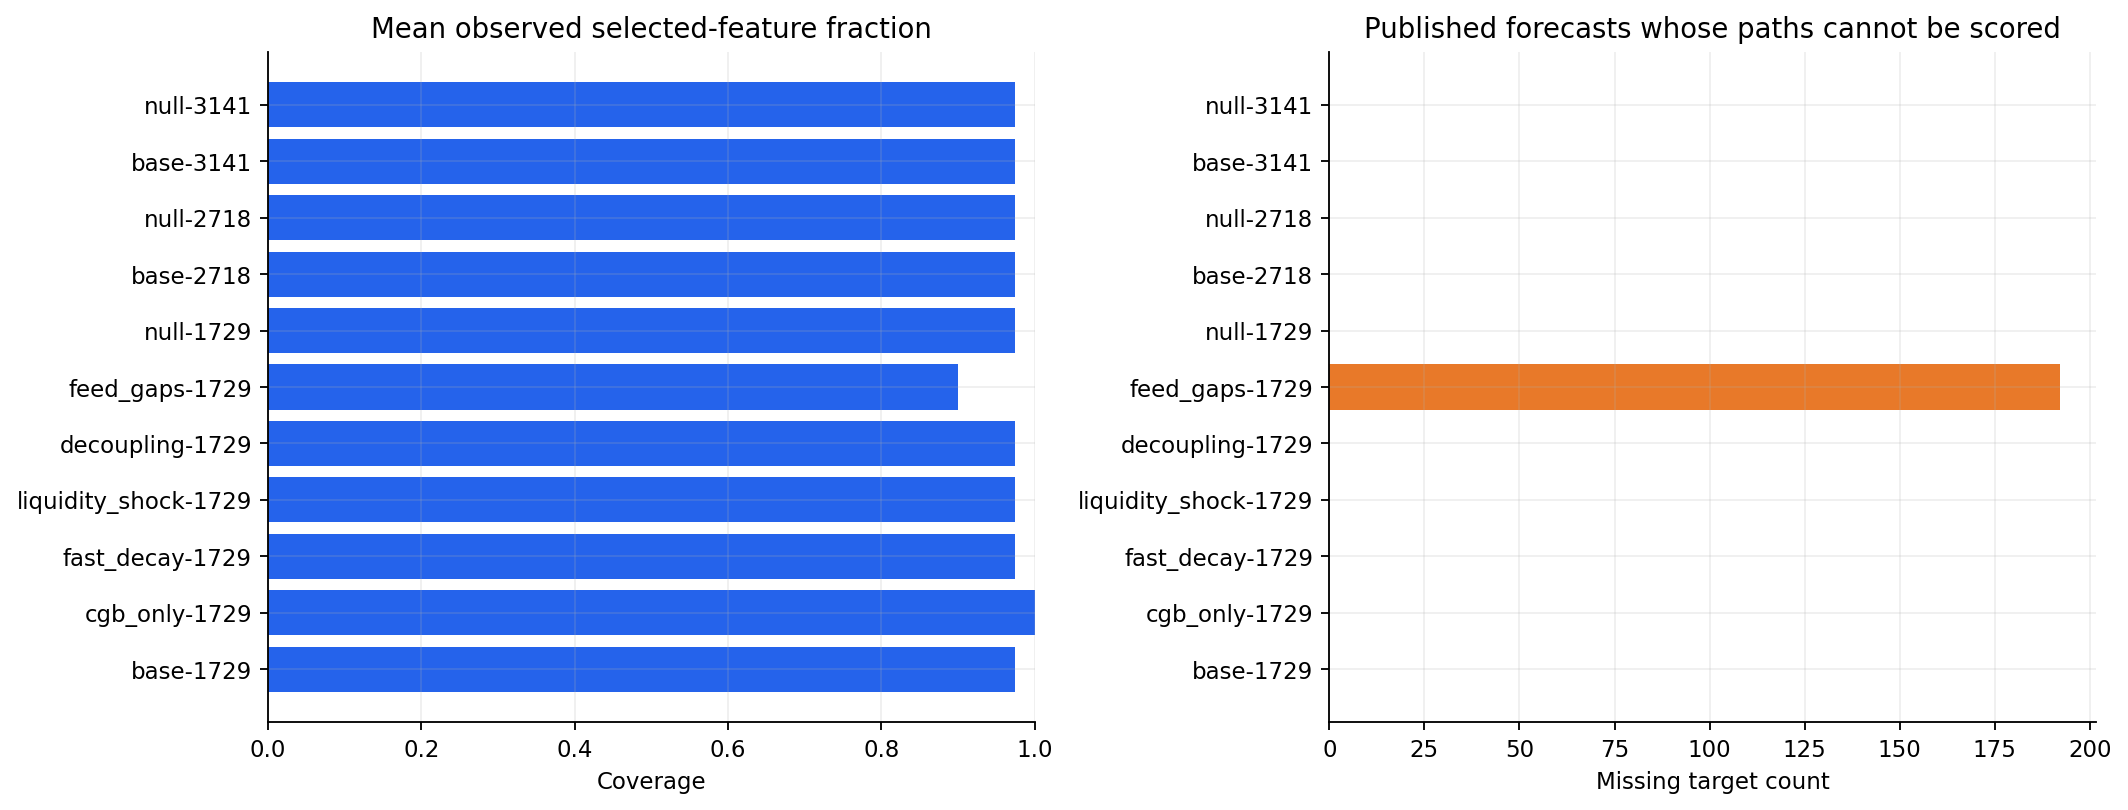

19-example-audit.png


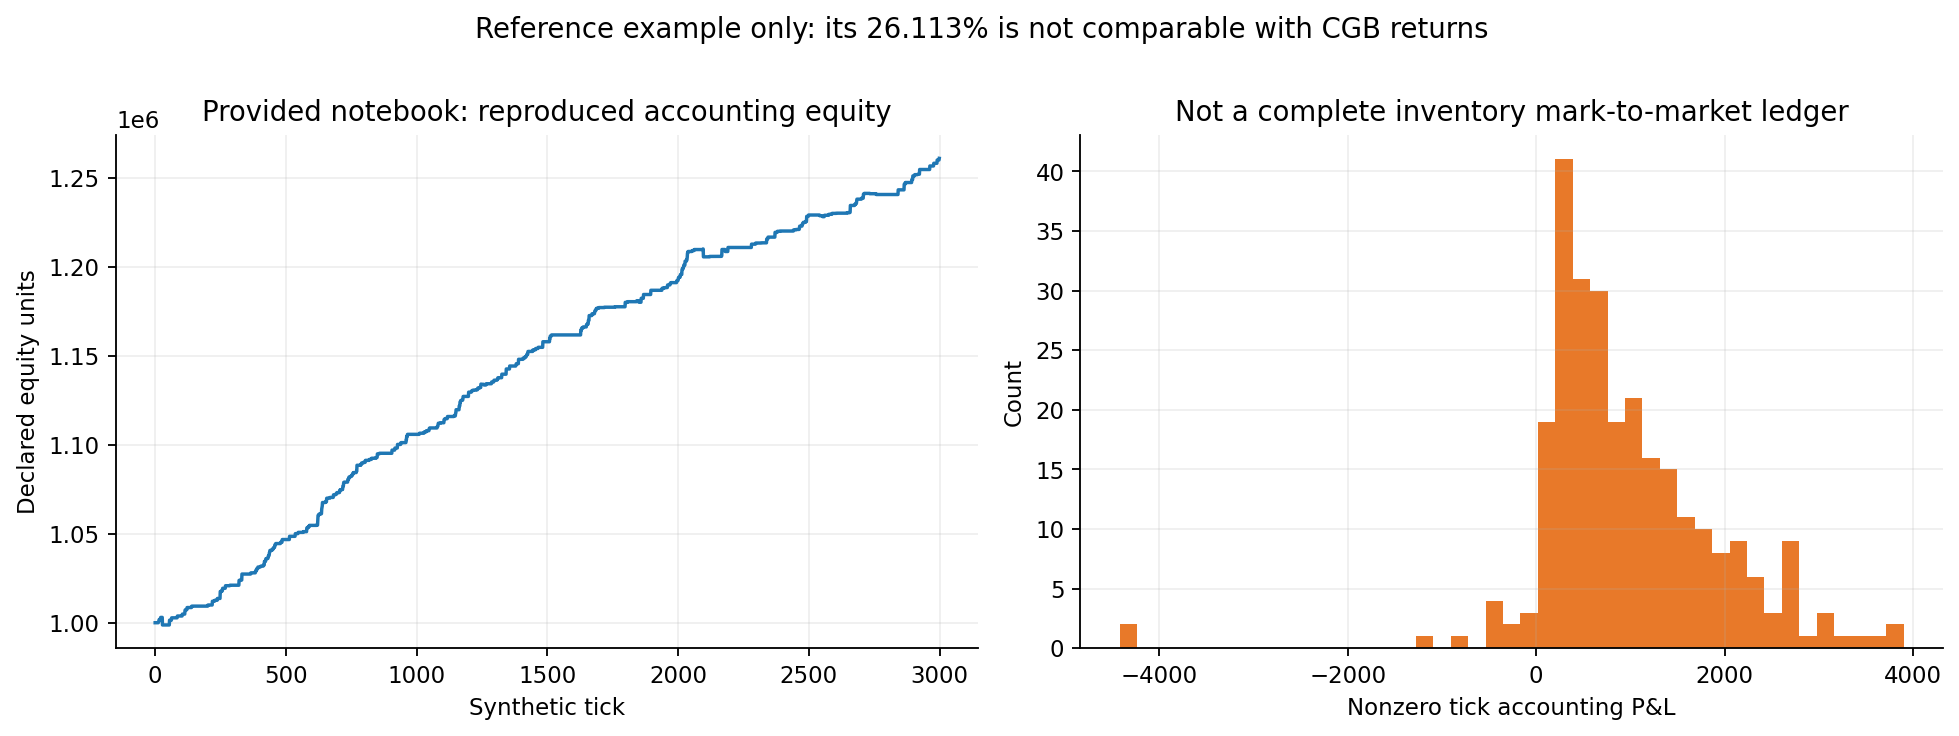

20-indicator-buckets.png


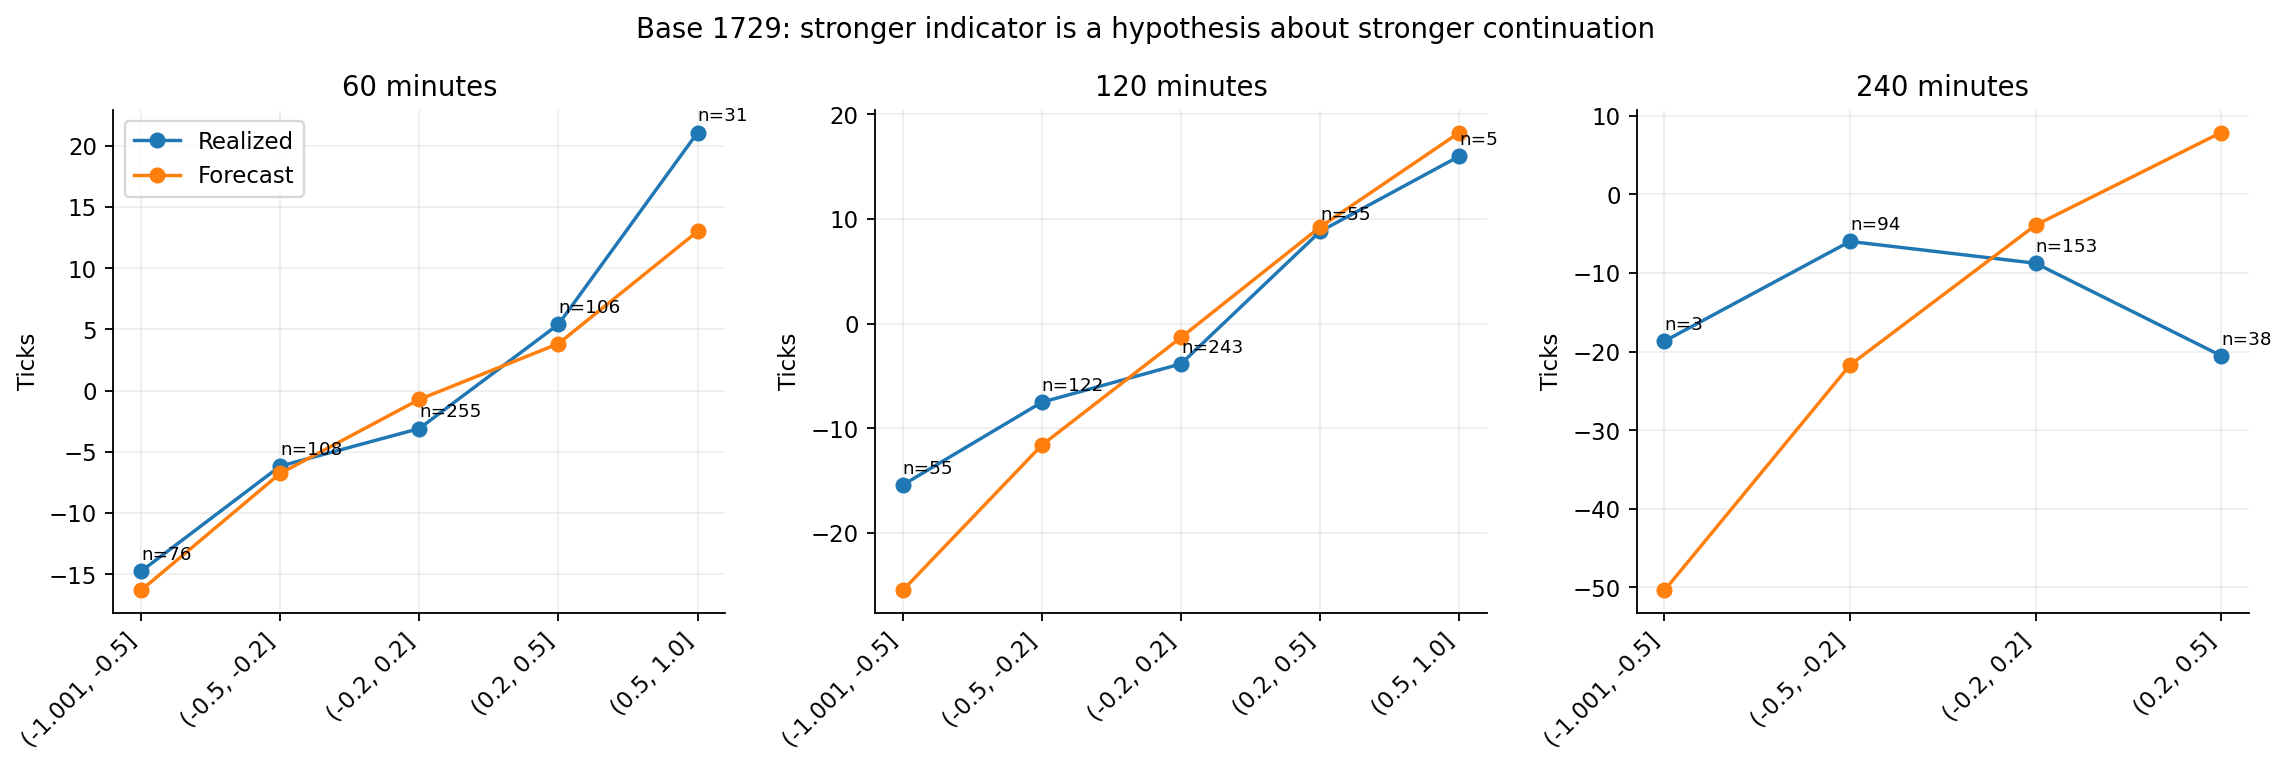

In [8]:
for number in range(15, 21):
    path = next((ROOT / 'figures').glob(f'{number:02d}-*.png'))
    print(path.name)
    display(Image(filename=str(path)))

## Bond curves, cash flows and risk matching

21-zero-curves.png


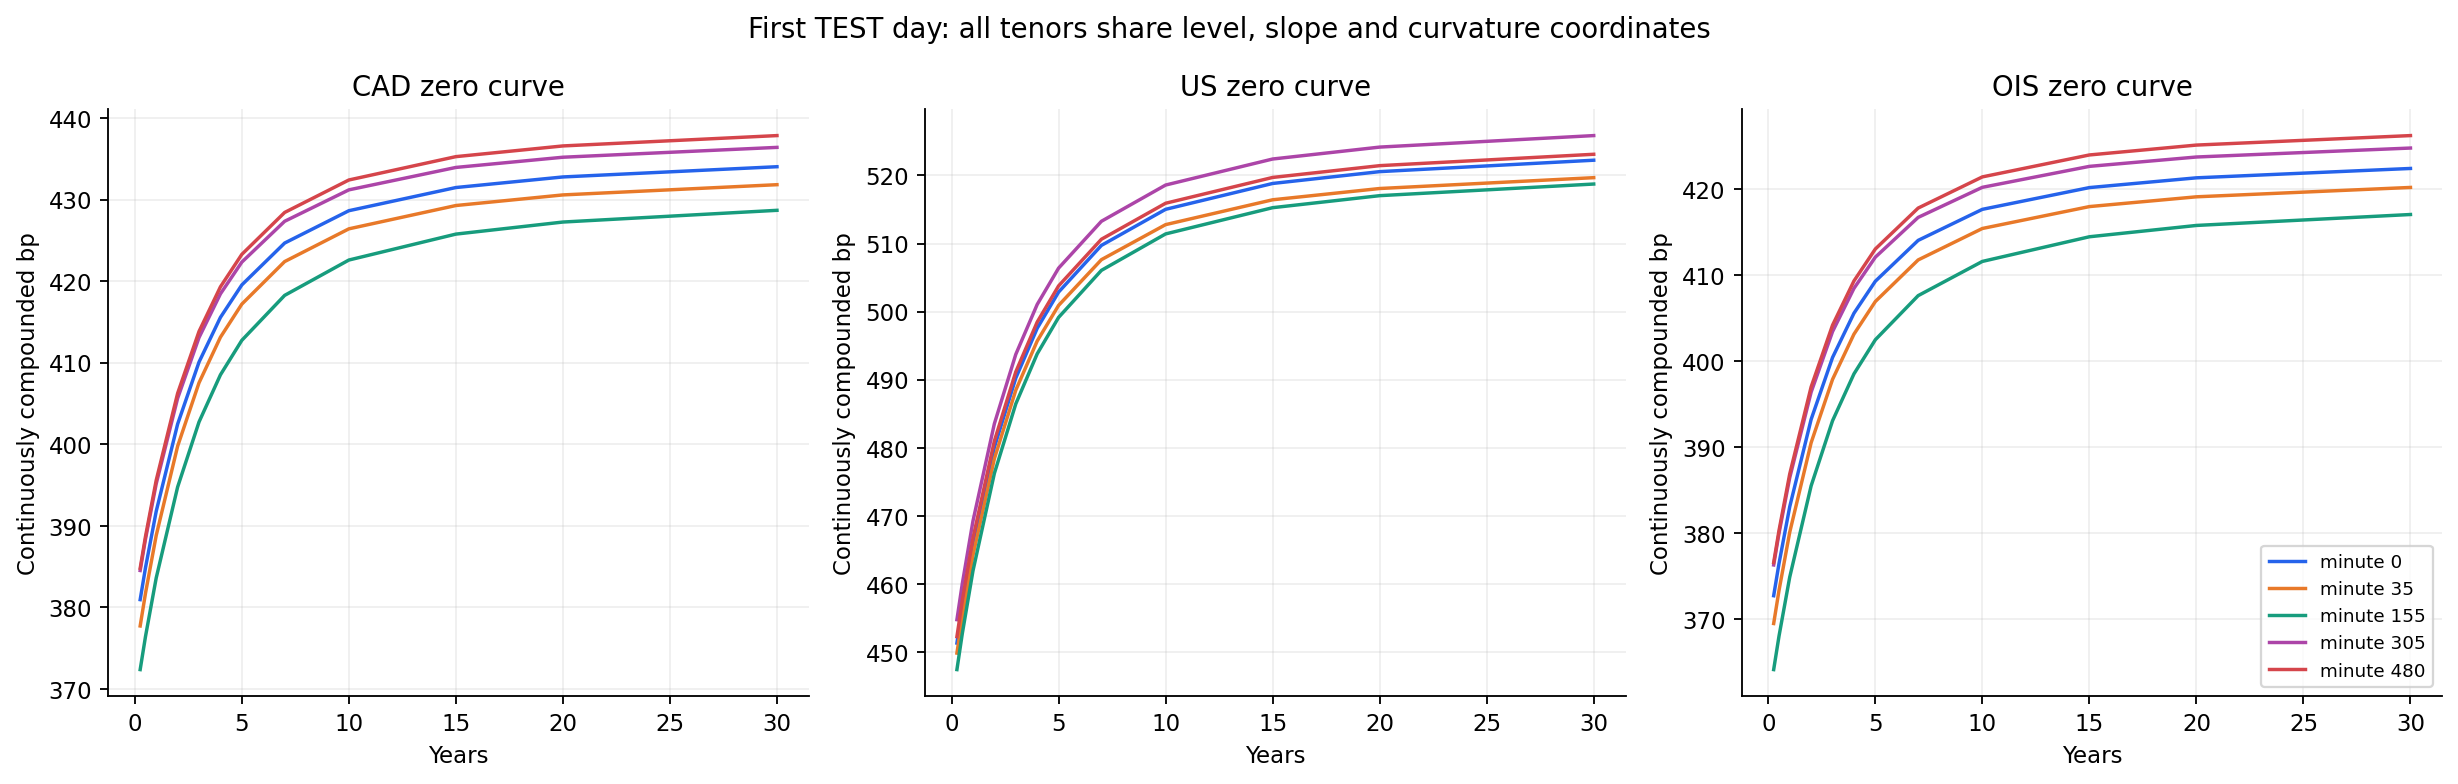

22-risk-units.png


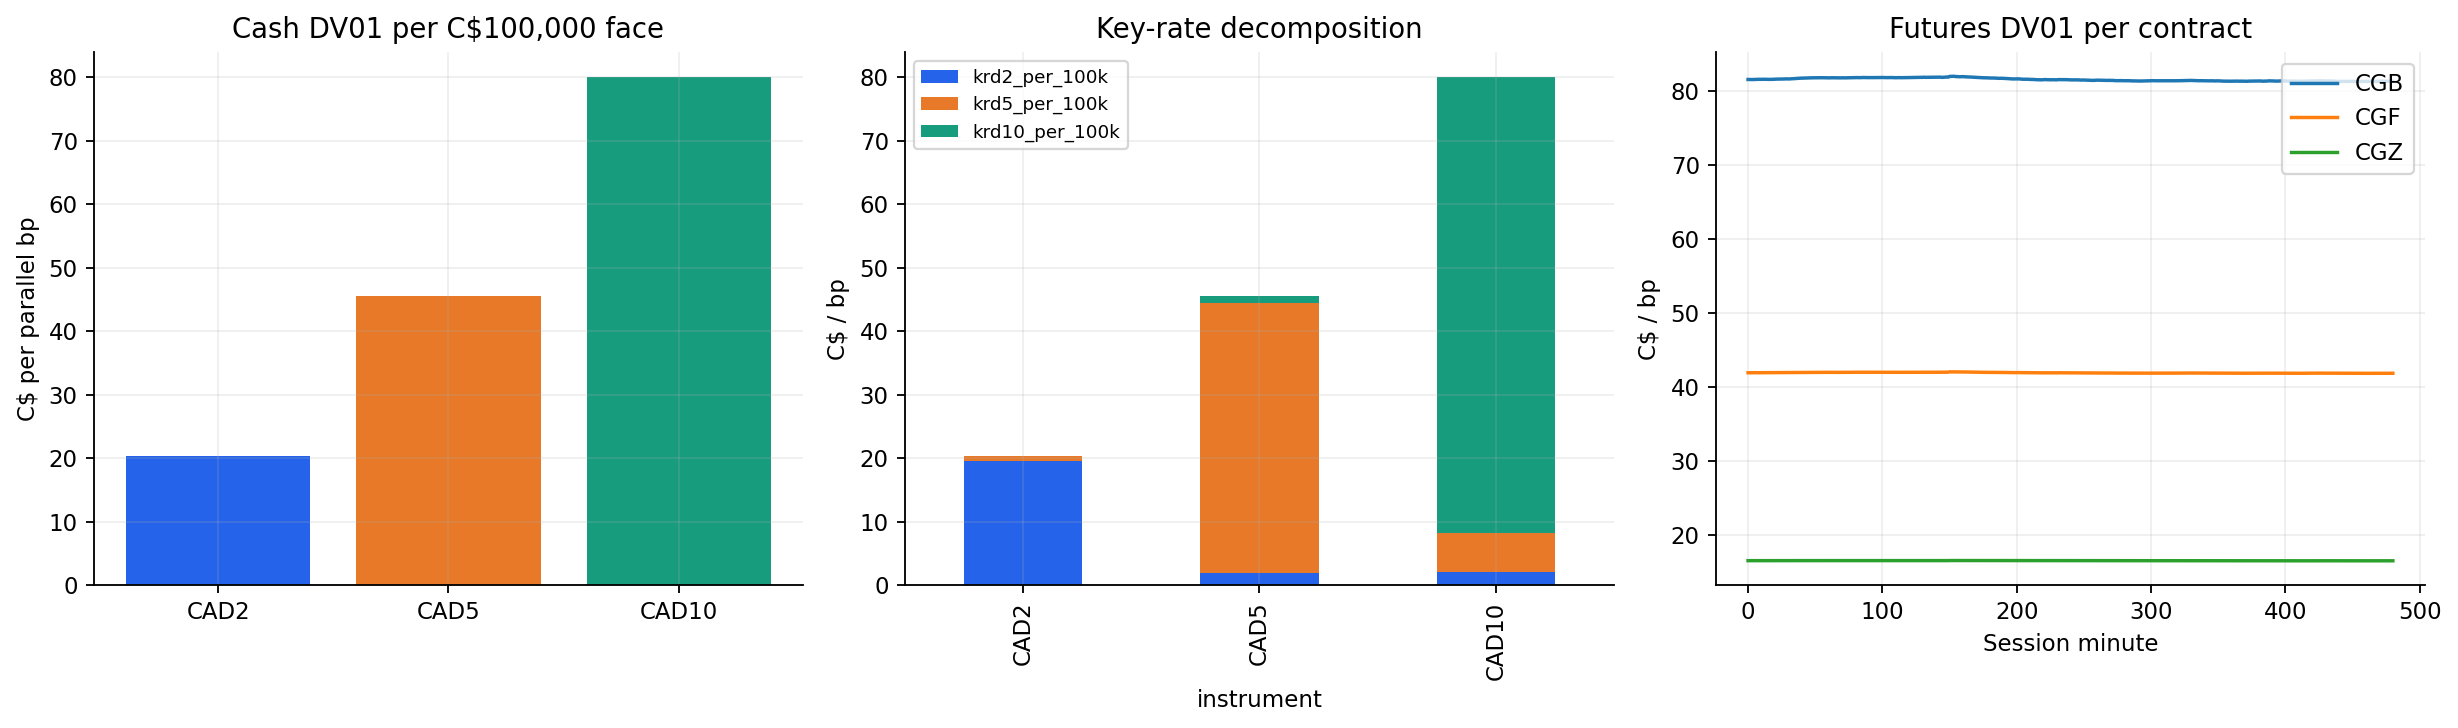

23-delivery-basket.png


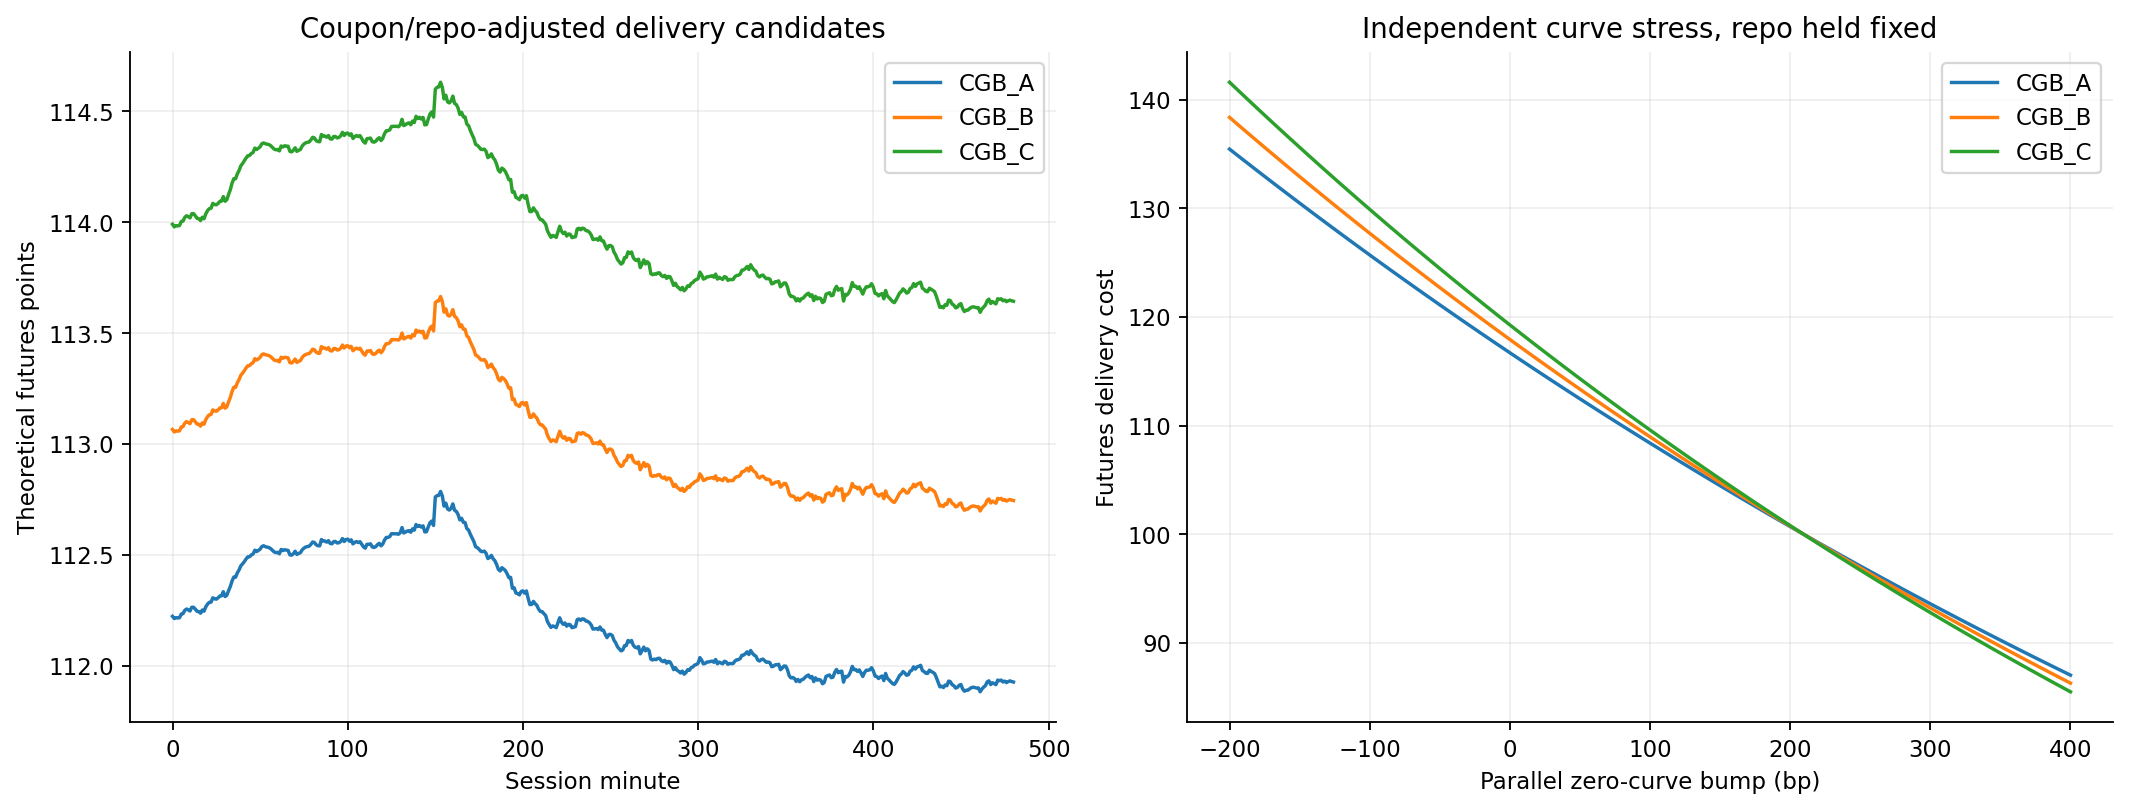

24-context.png


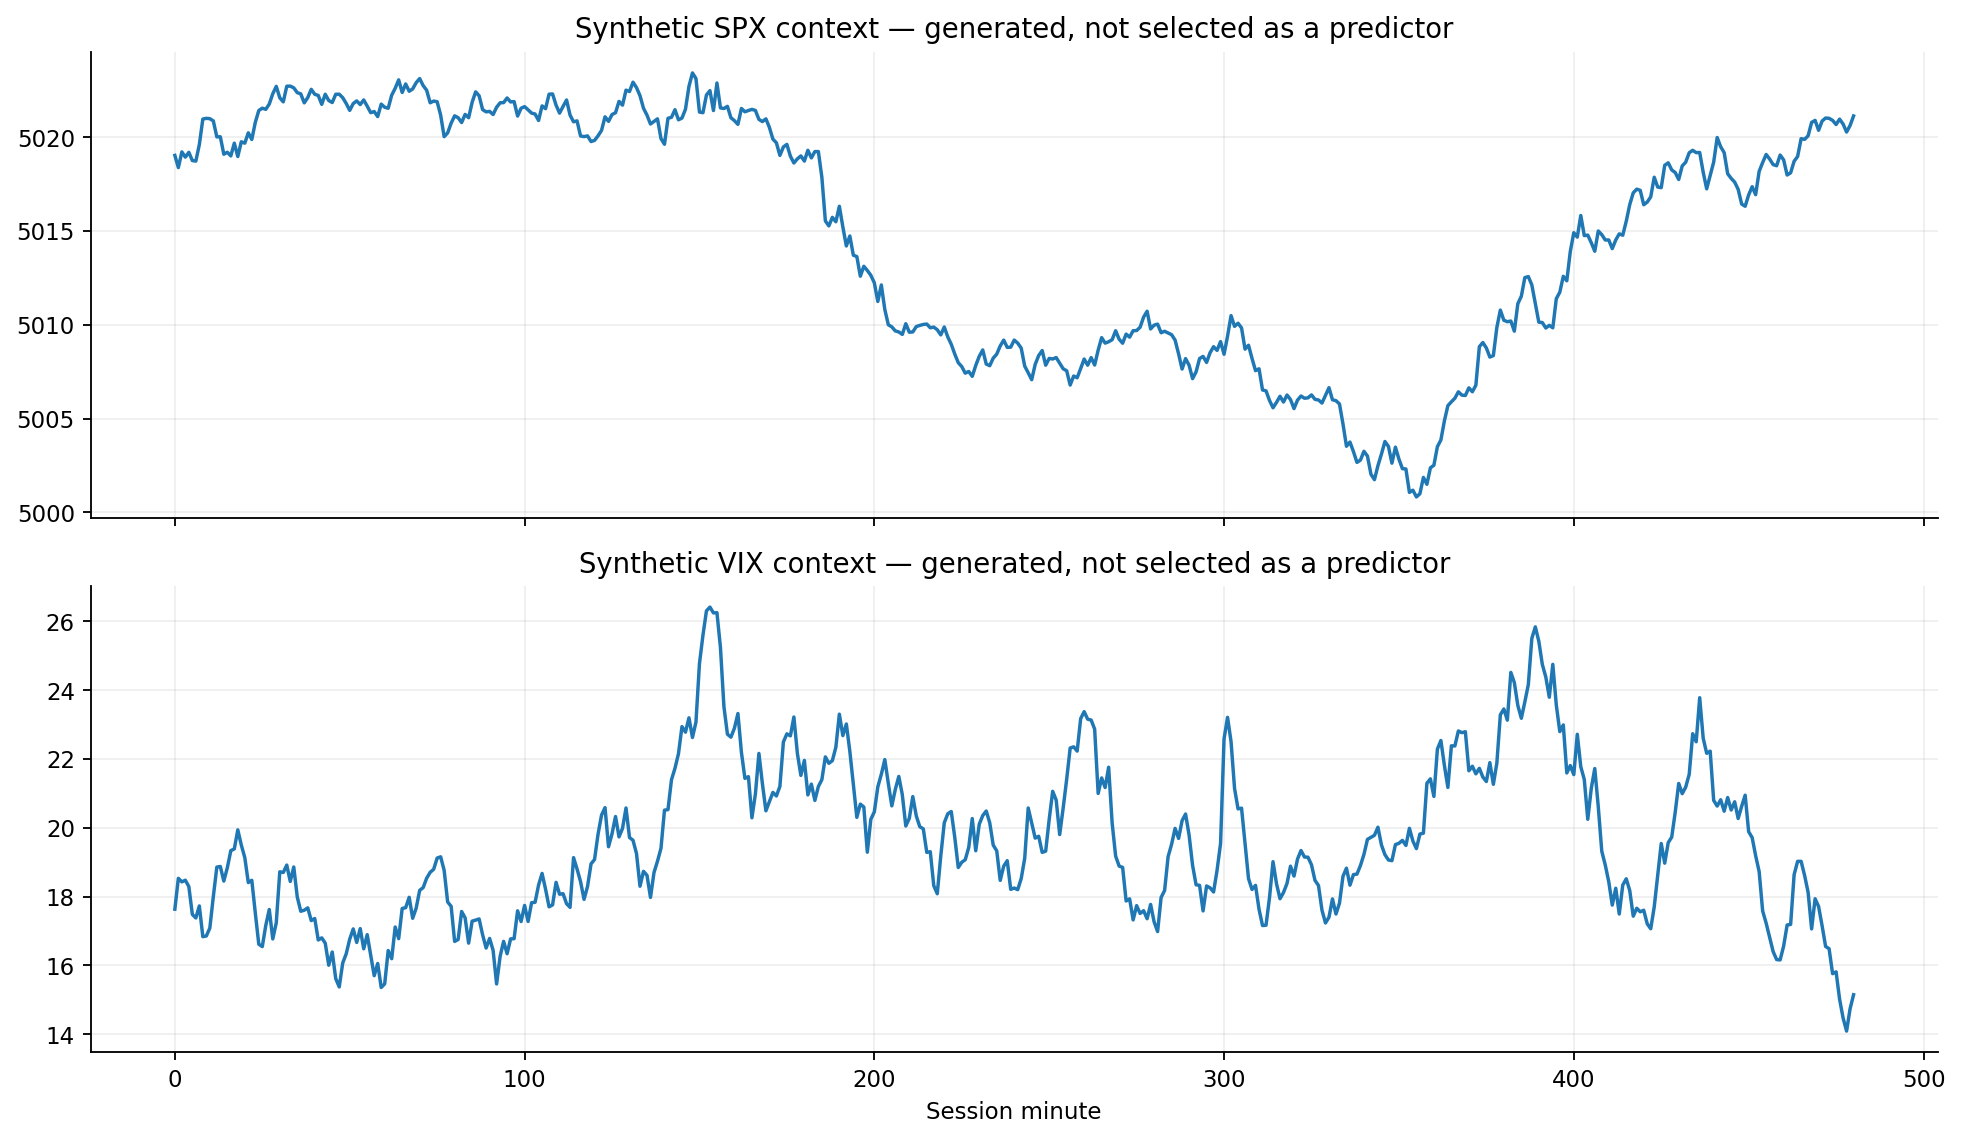

25-cash-versus-futures.png


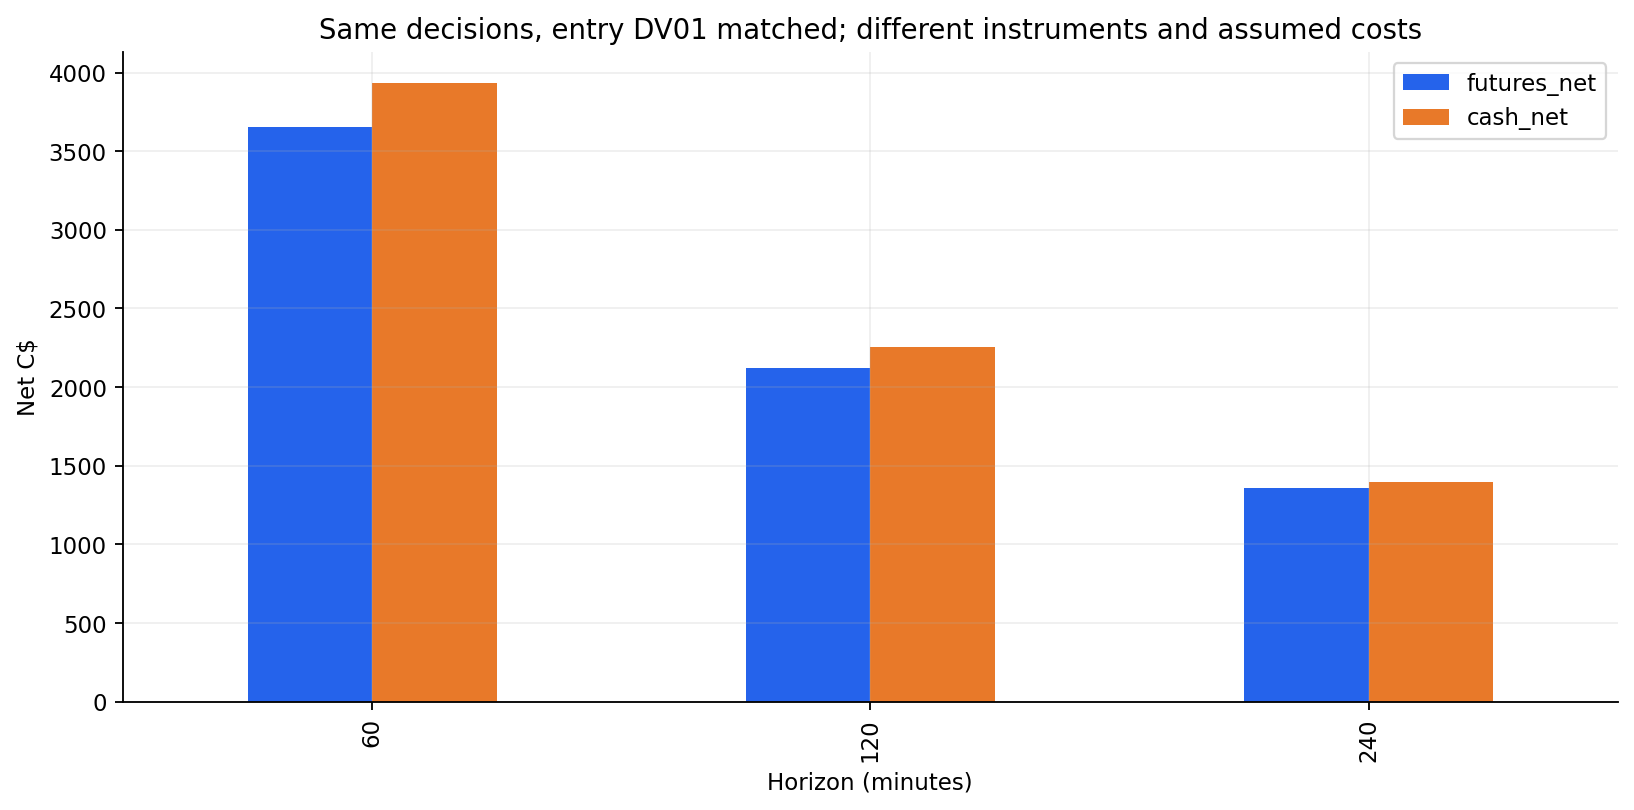

In [9]:
for number in range(21, 26):
    path = next((ROOT / 'figures').glob(f'{number:02d}-*.png'))
    print(path.name)
    display(Image(filename=str(path)))

## Every model trade in the first TEST history, and its cash-bond alternative

In [10]:
ledger = pd.read_csv(ROOT / 'results/base-1729/trade-ledger.csv')
print(ledger[ledger.strategy.eq('model')].to_string(index=False))
print(pd.read_csv(ROOT / 'cash-versus-futures-ledger.csv').to_string(index=False))

      run  horizon_minutes strategy session_id             decision_time                entry_time                 exit_time  direction  midpoint_change_cad  spread_crossing_cad  touch_change_cad  additional_slippage_cad  fees_cad  net_benchmark_cad                                   status  stress_net_cad  delayed_exit_minutes
base-1729               60    model 2025-02-19 2025-02-19 14:05:00+00:00 2025-02-19 14:06:00+00:00 2025-02-19 15:05:00+00:00          1                 75.0                 15.0              60.0                     10.0       4.0               46.0 price_touch_benchmark_not_verified_fills            16.0                   0.0
base-1729               60    model 2025-02-19 2025-02-19 15:35:00+00:00 2025-02-19 15:36:00+00:00 2025-02-19 16:35:00+00:00         -1                545.0                 15.0             530.0                     10.0       4.0              516.0 price_touch_benchmark_not_verified_fills           486.0                   0.0
base-1729    

## Verification and boundaries

Passing these tests establishes identities and replay behavior on the supplied synthetic inputs. It does not establish market alpha. The Markdown report explains uncalibrated mechanisms, the limited control world, unsupported tails, missing-data cases and the independent next tests.

In [11]:
print(json.dumps(json.loads((ROOT / 'verification.json').read_text()), indent=2))
print(json.dumps(json.loads((ROOT / 'render-verification.json').read_text()), indent=2))
assert len(metrics) == 33
assert len(list((ROOT / 'figures').glob('*.png'))) == 25

{
  "checks": [
    {
      "check": "quote_units_and_clocks",
      "status": "PASS",
      "detail": "Positive uncrossed prices; CGB bid/ask on 0.01 lattice; positive depth; event <= arrival."
    },
    {
      "check": "curve_identities_and_short_history",
      "status": "PASS",
      "detail": "Annual effective forwards satisfy discount-ratio identities; swaps exist only in last four TEST sessions."
    },
    {
      "check": "cashflow_curve_and_futures_identities",
      "status": "PASS",
      "detail": "Positive decreasing discount factors; dirty = clean + accrued; positive DV01; key-rate sum within C$0.0001 per 100k; YTM inversion; coupon-aware repo carry and cheapest delivery selection."
    },
    {
      "check": "model_and_path_integrity",
      "status": "PASS",
      "detail": "Frozen deployment hashes verified; TRAIN-only scenario dates; stochastic matrices; coherent scenario excursions; no hidden truth columns selected."
    },
    {
      "check": "all_forecast_and_